# Data Extraction
Loading the data, column selection, SEQNO duplicate investigation, composite respondent_id fix, and some recoding stubs.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder = "/content/drive/MyDrive/ADSP 31012 DEPA Final Project/1. Raw Data"

In [ ]:
import pandas as pd
import numpy as np
import re

In [ ]:
# Load the clean CSV saved from EDA
#BRFSS = pd.read_csv(f"{folder}/EDA and Cleanup/BRFSS_2024_clean.csv")

df_raw = pd.read_sas(folder + "/LLCP2024.XPT_", format="xport", encoding="latin1")
print(df_raw.shape)
print(df_raw.head())

(457670, 301)
   _STATE  FMONTH     IDATE IMONTH IDAY IYEAR  DISPCODE       SEQNO  \
0     1.0     2.0  02282024     02   28  2024    1100.0  2024000001   
1     1.0     2.0  02212024     02   21  2024    1100.0  2024000002   
2     1.0     2.0  02212024     02   21  2024    1100.0  2024000003   
3     1.0     2.0  02282024     02   28  2024    1100.0  2024000004   
4     1.0     2.0  02212024     02   21  2024    1100.0  2024000005   

           _PSU  CTELENM1  ...  _LCSCTSN  _LCSPSTF  DRNKANY6      DROCDY4_  \
0  2.024000e+09       1.0  ...       NaN       9.0       2.0  5.397605e-79   
1  2.024000e+09       1.0  ...       4.0       9.0       2.0  5.397605e-79   
2  2.024000e+09       1.0  ...       4.0       2.0       1.0  1.000000e+02   
3  2.024000e+09       1.0  ...       NaN       9.0       2.0  5.397605e-79   
4  2.024000e+09       1.0  ...       3.0       9.0       2.0  5.397605e-79   

   _RFBING6      _DRNKWK3  _RFDRHV9  _FLSHOT7  _PNEUMO3  _AIDTST4  
0       1.0  5.397605e

In [ ]:
NEEDED = [
    'SEQNO','_STATE','_LLCPWT','IMONTH','IDAY','IYEAR',
    '_METSTAT','_URBSTAT','MSCODE',
    '_SEX','_AGEG5YR','_RACE','_HISPANC','_EDUCAG','_INCOMG1',
    'MARITAL','EMPLOY1','CHILDREN','VETERAN3','PREGNANT',
    'GENHLTH','PHYSHLTH','MENTHLTH','_BMI5','_BMI5CAT',
    'CVDINFR4','CVDSTRK3','DIABETE4','ASTHMA3','ADDEPEV3',
    'CHCCOPD3','HAVARTH4','CHCOCNC1','CHCKDNY2','LSATISFY',
    'EXERANY2','_SMOKER3','ECIGNOW3','DRNKANY6','_RFBING6',
    '_RFDRHV9','AVEDRNK4','MARIJAN1','SSBSUGR2','FIREARM5',
    '_HLTHPL2','PRIMINS2','PERSDOC3','MEDCOST1','CHECKUP1',
    'LASTDEN4','_RFMAM23','_CRVSCRN','_CRCREC3',
    '_FLSHOT7','_PNEUMO3','_AIDTST4','SDHFOOD1','SDHTRNSP',
    'QSTVER','QSTLANG','CELLFON5'
]

df = df_raw[NEEDED].copy()

print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Raw shape: (457670, 62)
Columns: ['SEQNO', '_STATE', '_LLCPWT', 'IMONTH', 'IDAY', 'IYEAR', '_METSTAT', '_URBSTAT', 'MSCODE', '_SEX', '_AGEG5YR', '_RACE', '_HISPANC', '_EDUCAG', '_INCOMG1', 'MARITAL', 'EMPLOY1', 'CHILDREN', 'VETERAN3', 'PREGNANT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', '_BMI5', '_BMI5CAT', 'CVDINFR4', 'CVDSTRK3', 'DIABETE4', 'ASTHMA3', 'ADDEPEV3', 'CHCCOPD3', 'HAVARTH4', 'CHCOCNC1', 'CHCKDNY2', 'LSATISFY', 'EXERANY2', '_SMOKER3', 'ECIGNOW3', 'DRNKANY6', '_RFBING6', '_RFDRHV9', 'AVEDRNK4', 'MARIJAN1', 'SSBSUGR2', 'FIREARM5', '_HLTHPL2', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'LASTDEN4', '_RFMAM23', '_CRVSCRN', '_CRCREC3', '_FLSHOT7', '_PNEUMO3', '_AIDTST4', 'SDHFOOD1', 'SDHTRNSP', 'QSTVER', 'QSTLANG', 'CELLFON5']


# EDA
Distributions, missing values visualization, weighted vs unweighted comparisons, outcome prevalence, geographic breakdown, correlations, and demographic cross-tabs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})
sns.set_theme(style="whitegrid", palette="muted")

# ── Variable groups ───────────────────────────────────────────
ADMIN_VARS     = ['SEQNO', 'IMONTH', 'IDAY', 'IYEAR',
                  'QSTVER', 'QSTLANG', 'CELLFON5']

GEO_VARS       = ['_STATE', '_METSTAT', '_URBSTAT', 'MSCODE']

DEMO_VARS      = ['_SEX', '_AGEG5YR', '_RACE', '_HISPANC', '_EDUCAG',
                  '_INCOMG1', 'MARITAL', 'EMPLOY1', 'VETERAN3',
                  'CHILDREN', 'PREGNANT']

OUTCOME_VARS   = ['CVDINFR4', 'CVDSTRK3', 'DIABETE4', 'ASTHMA3',
                  'ADDEPEV3', 'CHCCOPD3', 'HAVARTH4', 'CHCOCNC1',
                  'CHCKDNY2']

BEHAVIOR_VARS  = ['EXERANY2', '_SMOKER3', 'ECIGNOW3', 'DRNKANY6',
                  '_RFBING6', '_RFDRHV9', 'AVEDRNK4', 'MARIJAN1',
                  'SSBSUGR2', 'FIREARM5']

HEALTH_VARS    = ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', '_BMI5', '_BMI5CAT',
                  'LSATISFY']

HEALTHCARE_VARS = ['_HLTHPL2', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1',
                   'CHECKUP1', 'LASTDEN4']

PREVENTION_VARS = ['_RFMAM23', '_CRVSCRN', '_CRCREC3',
                   '_FLSHOT7', '_PNEUMO3', '_AIDTST4']

SDH_VARS       = ['SDHFOOD1', 'SDHTRNSP']

WEIGHT_COL     = '_LLCPWT'

# ── Sanity check: every NEEDED column is assigned exactly once ──
ALL_GROUPED = (
    ADMIN_VARS + GEO_VARS + DEMO_VARS + OUTCOME_VARS +
    BEHAVIOR_VARS + HEALTH_VARS + HEALTHCARE_VARS +
    PREVENTION_VARS + SDH_VARS + [WEIGHT_COL]
)
missing  = [c for c in df.columns if c not in ALL_GROUPED]
orphaned = [c for c in ALL_GROUPED if c not in df.columns]
if missing:
    print(f"⚠ In df but ungrouped: {missing}")
if orphaned:
    print(f"⚠ In groups but not in df: {orphaned}")
if not missing and not orphaned:
    print(f"✓ All {len(ALL_GROUPED)} columns accounted for across {9} groups + weight")

# ── Friendly labels for outcomes ─────────────────────────────
OUTCOME_LABELS = {
    'CVDINFR4': 'Heart Attack',
    'CVDSTRK3': 'Stroke',
    'DIABETE4':  'Diabetes',
    'ASTHMA3':   'Asthma',
    'ADDEPEV3':  'Depression',
    'CHCCOPD3':  'COPD',
    'HAVARTH4':  'Arthritis',
    'CHCOCNC1':  'Cancer',
    'CHCKDNY2':  'Kidney Disease',
}

YES_CODE = 1.0

✓ All 62 columns accounted for across 9 groups + weight


## Section 1: Data Overview

In [ ]:
# ── Section 1: Data Overview ──────────────────────────────────
print(f"Shape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage  : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn dtypes:\n{df.dtypes.value_counts()}")
print(f"\nSample rows:")
display(df.head(3))

print(f"\nDescriptive stats (numeric):")
display(df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']])

Shape         : 457,670 rows × 62 columns
Memory usage  : 310.3 MB

Column dtypes:
float64    58
object      4
Name: count, dtype: int64

Sample rows:


,SEQNO,_STATE,_LLCPWT,IMONTH,IDAY,IYEAR,_METSTAT,_URBSTAT,MSCODE,_SEX,...,_CRVSCRN,_CRCREC3,_FLSHOT7,_PNEUMO3,_AIDTST4,SDHFOOD1,SDHTRNSP,QSTVER,QSTLANG,CELLFON5
0,2024000001,1.0,261.525511,02,28,2024,1.0,1.0,1.0,2.0,...,1.0,NaN,1.0,2.0,2.0,5.0,2.0,10.0,1.0,NaN
1,2024000002,1.0,307.169688,02,21,2024,1.0,1.0,1.0,1.0,...,NaN,NaN,1.0,1.0,2.0,5.0,2.0,10.0,1.0,NaN
2,2024000003,1.0,2939.862806,02,21,2024,2.0,1.0,5.0,1.0,...,NaN,3.0,NaN,NaN,2.0,5.0,2.0,10.0,1.0,NaN



Descriptive stats (numeric):


,count,mean,std,min,50%,max
_STATE,457670.0,30.823537,15.939364,1.000000e+00,31.000000,78.000000
_LLCPWT,457670.0,576.361549,1171.591566,1.228580e-02,263.739622,49582.191041
_METSTAT,443047.0,1.284322,0.451091,1.000000e+00,1.000000,2.000000
_URBSTAT,443047.0,1.134961,0.341682,1.000000e+00,1.000000,2.000000
MSCODE,80024.0,2.912001,1.799604,1.000000e+00,3.000000,5.000000
_SEX,457670.0,1.524751,0.499388,1.000000e+00,2.000000,2.000000
_AGEG5YR,457670.0,7.781845,3.738928,1.000000e+00,8.000000,14.000000
_RACE,457670.0,2.287550,2.511348,1.000000e+00,1.000000,9.000000
_HISPANC,457670.0,1.974237,0.818120,1.000000e+00,2.000000,9.000000
_EDUCAG,457670.0,3.077680,1.043475,1.000000e+00,3.000000,9.000000


* The working dataset has 457,670 respondents across 62 selected columns — one fewer than the old notes stated (62, not 63), now cleanly distributed across 9 variable groups plus the survey weight.
* All columns are numeric (float64), consistent with the XPT source format — no parsing or dtype conversion needed before analysis.

## Section 2: Missing Values

43 of 62 columns have missing values

  column  pct_missing
  MSCODE    82.514912
PREGNANT    82.222344
FIREARM5    76.911967
SSBSUGR2    74.741189
MARIJAN1    70.102476
_PNEUMO3    60.813687
_FLSHOT7    60.813687
_RFMAM23    58.758713
SDHTRNSP    55.921516
SDHFOOD1    55.764197
LSATISFY    55.477964
_CRVSCRN    55.001857
AVEDRNK4    54.082417
_CRCREC3    50.259576
CELLFON5    17.858064
_AIDTST4     9.502917
   _BMI5     9.403500
_BMI5CAT     9.403500
ECIGNOW3     6.702646
_URBSTAT     3.195097
_METSTAT     3.195097
CHILDREN     1.224900
 EMPLOY1     0.721699
VETERAN3     0.269845
 MARITAL     0.001966
CHCCOPD3     0.001529
MEDCOST1     0.001311
CHCKDNY2     0.001311
 GENHLTH     0.001092
ADDEPEV3     0.001092
CHCOCNC1     0.001092
PHYSHLTH     0.001092
HAVARTH4     0.001092
DIABETE4     0.000874
PERSDOC3     0.000655
EXERANY2     0.000655
PRIMINS2     0.000655
 ASTHMA3     0.000655
MENTHLTH     0.000655
CVDSTRK3     0.000655
CHECKUP1     0.000437
LASTDEN4     0.000437
CVDINFR4     0.0

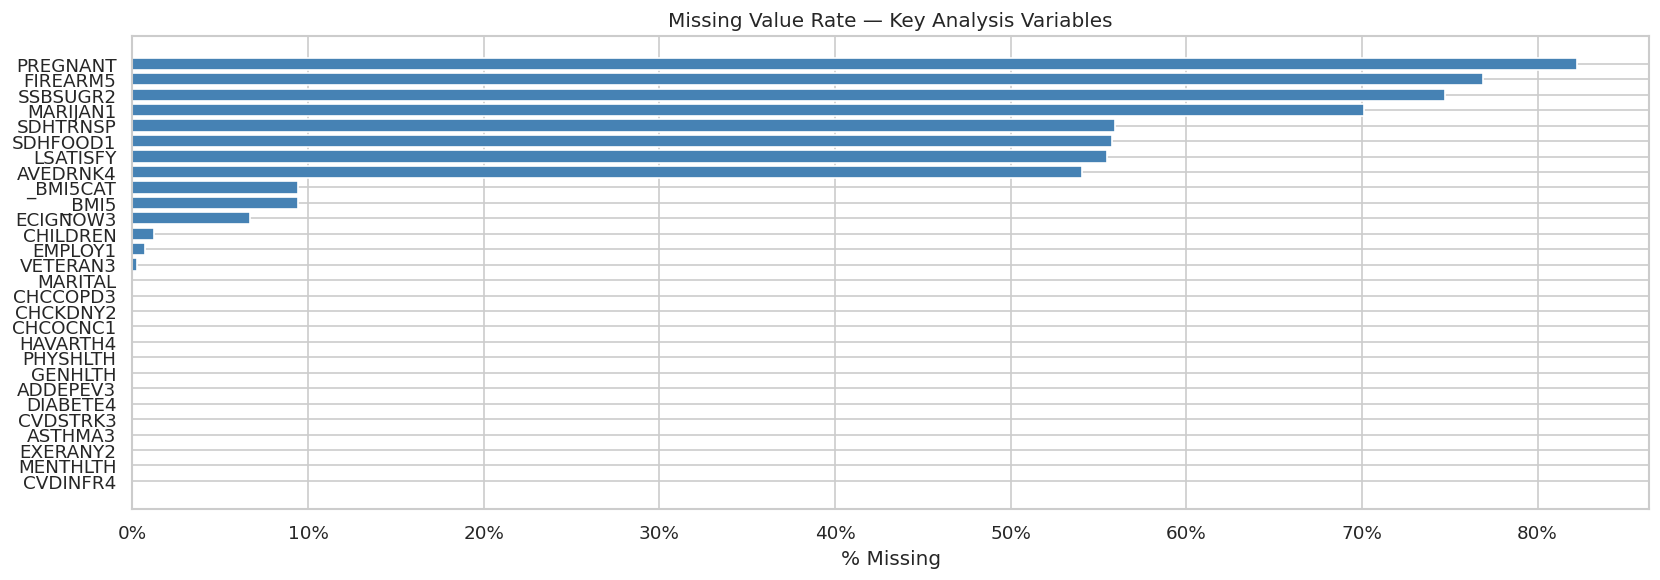

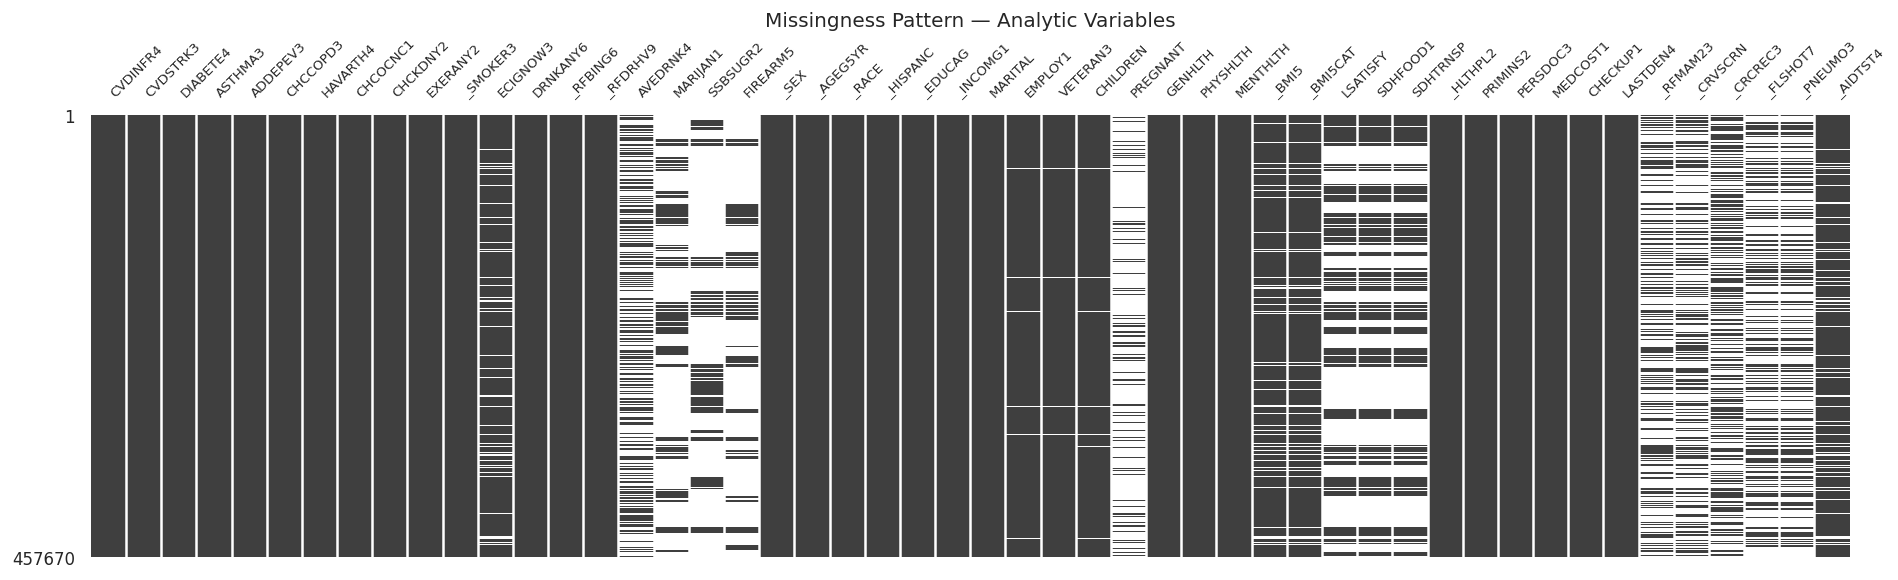

In [ ]:
# ── 2a. Overall missing rate per column ───────────────────────
miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['column', 'pct_missing']
print(f"{len(miss_df)} of {df.shape[1]} columns have missing values\n")
print(miss_df.to_string(index=False))

# ── 2b. Bar chart — key analysis variables only ───────────────
key_cols = [c for c in OUTCOME_VARS + BEHAVIOR_VARS + DEMO_VARS + HEALTH_VARS + SDH_VARS
            if c in miss_df['column'].values]
subset = miss_df[miss_df['column'].isin(key_cols)].sort_values('pct_missing', ascending=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(subset['column'], subset['pct_missing'], color='steelblue')
ax.set_xlabel("% Missing")
ax.set_title("Missing Value Rate — Key Analysis Variables")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

# ── 2c. Missingno matrix for a visual pattern check ───────────
analytic_cols = OUTCOME_VARS + BEHAVIOR_VARS + DEMO_VARS + HEALTH_VARS + SDH_VARS + HEALTHCARE_VARS + PREVENTION_VARS
msno.matrix(df[analytic_cols], figsize=(16, 5), sparkline=False, fontsize=8)
plt.title("Missingness Pattern — Analytic Variables")
plt.tight_layout()
plt.show()

* 43 of 62 columns have missing values, but the pattern is structural, not random — it splits cleanly into two tiers.
* High-missingness columns (>50%) are optional state-administered modules: PREGNANT (82%), MSCODE (83%), FIREARM5 (77%), SSBSUGR2 (75%), MARIJAN1 (70%), and most of PREVENTION_VARS and SDH_VARS (~50–61%). These were not administered by all states and cannot be treated as MCAR — they should be used only where available or excluded from any population-level model.
* Core outcome, behavior, and demographic variables are nearly complete (<1% missing), making them reliable for analysis without imputation.
* _BMI5 and _BMI5CAT share an identical 9.4% missing rate, confirming they're derived from the same underlying question — treat their missingness as one unit.
* ECIGNOW3 is 6.7% missing, likely because it routes only to current or recent smokers — missingness here is by design, not nonresponse.

## Section 3: Survey Weight Analysis

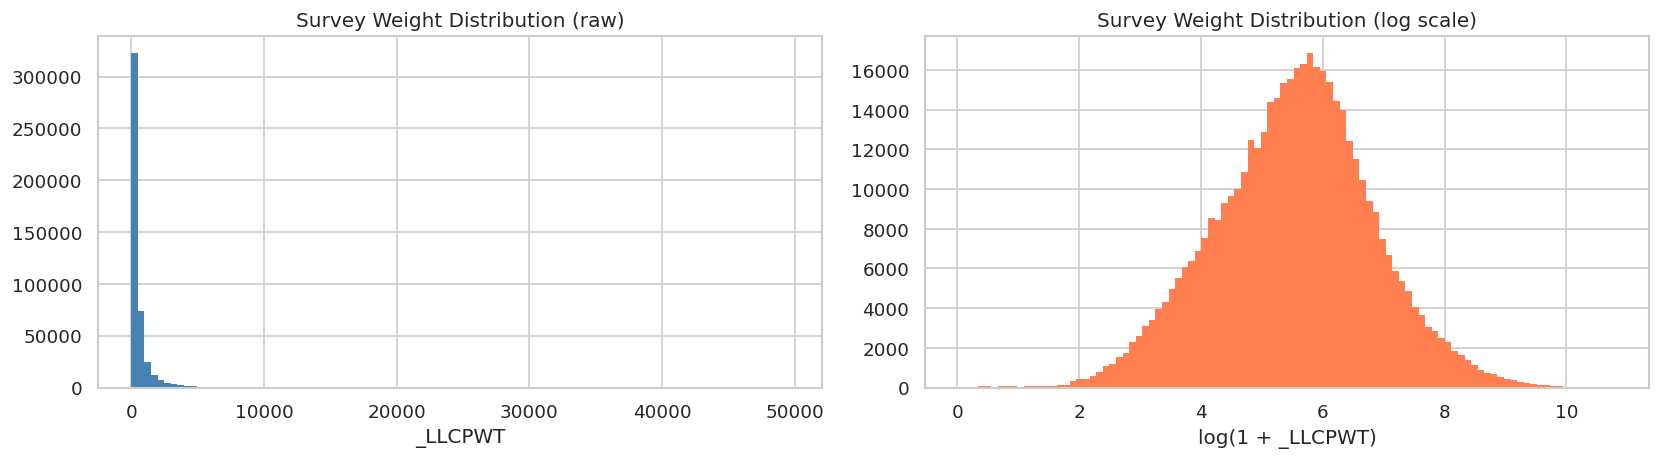


Weight stats:
count    457670.000000
mean        576.361549
std        1171.591566
min           0.012286
25%         106.608408
50%         263.739622
75%         581.612255
max       49582.191041
Name: _LLCPWT, dtype: float64

Weighted vs Unweighted Prevalence:


,Condition,Unweighted %,Weighted %
6,Arthritis,34.59,26.40
4,Depression,21.00,20.91
3,Asthma,15.74,15.66
2,Diabetes,14.38,12.50
7,Cancer,12.01,8.35
5,COPD,8.07,6.27
0,Heart Attack,5.83,4.35
8,Kidney Disease,5.19,4.11
1,Stroke,4.51,3.52


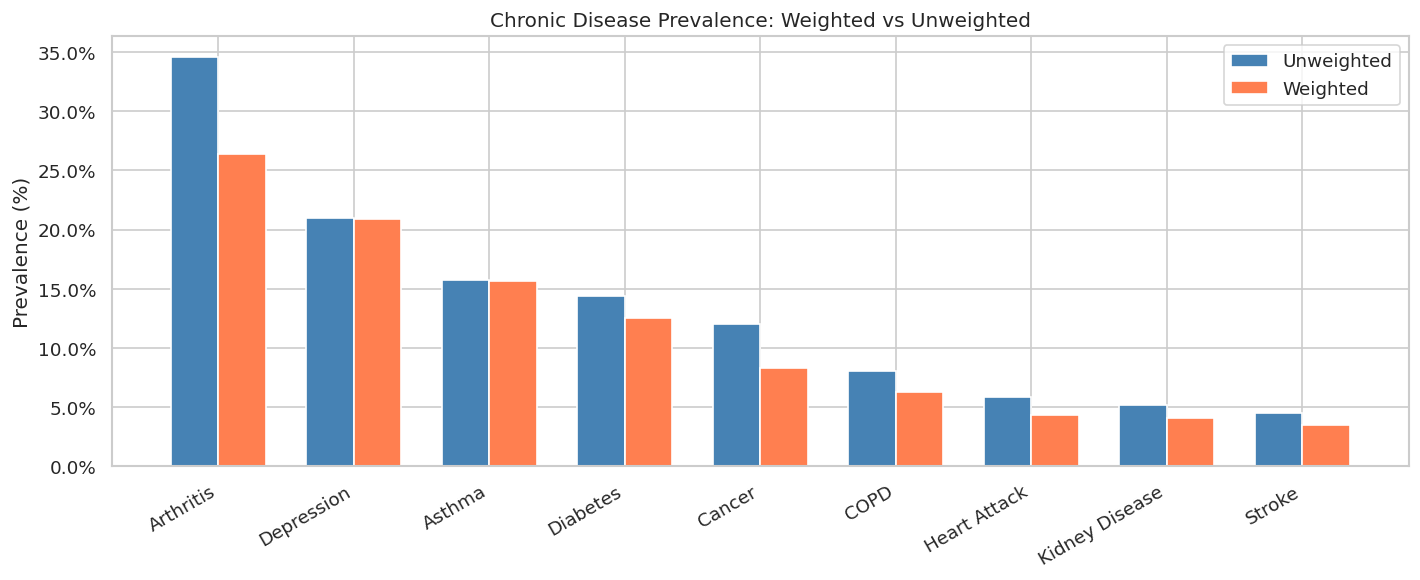

In [ ]:
# ── 3a. Weight distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df[WEIGHT_COL].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title("Survey Weight Distribution (raw)")
axes[0].set_xlabel("_LLCPWT")
np.log1p(df[WEIGHT_COL]).hist(bins=100, ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title("Survey Weight Distribution (log scale)")
axes[1].set_xlabel("log(1 + _LLCPWT)")
plt.tight_layout()
plt.show()

print(f"\nWeight stats:\n{df[WEIGHT_COL].describe()}")

# ── 3b. Weighted vs unweighted outcome prevalence ─────────────
def weighted_prevalence(series, weights, yes_val=1.0):
    mask = series.notna() & weights.notna()
    s, w = series[mask].astype(float), weights[mask]
    return (w[s == yes_val].sum() / w.sum()) * 100

records = []
for col, label in OUTCOME_LABELS.items():
    uw = (df[col].astype(float) == YES_CODE).mean() * 100
    wt = weighted_prevalence(df[col], df[WEIGHT_COL])
    records.append({'Condition': label, 'Unweighted %': round(uw, 2), 'Weighted %': round(wt, 2)})

prev_df = pd.DataFrame(records).sort_values('Weighted %', ascending=False)
print("\nWeighted vs Unweighted Prevalence:")
display(prev_df)

fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(prev_df)), 0.35
ax.bar(x - w/2, prev_df['Unweighted %'], w, label='Unweighted', color='steelblue')
ax.bar(x + w/2, prev_df['Weighted %'],   w, label='Weighted',   color='coral')
ax.set_xticks(x)
ax.set_xticklabels(prev_df['Condition'], rotation=30, ha='right')
ax.set_ylabel("Prevalence (%)")
ax.set_title("Chronic Disease Prevalence: Weighted vs Unweighted")
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

* Weights are extremely right-skewed: median of 264 vs. a mean of 576 and a max of nearly 50,000, meaning a small number of respondents represent very large population segments. This is expected for BRFSS's complex multistage design.
* Weighting consistently reduces prevalence estimates across all nine conditions, most sharply for Arthritis (34.6% → 26.4%) and Cancer (12.0% → 8.4%). The raw sample over-represents older, sicker respondents relative to the US adult population.
* Depression is the most stable estimate across weighting (21.0% → 20.9%), suggesting it is distributed more uniformly across the demographic groups that BRFSS over- and under-samples.
* All downstream prevalence figures should use weighted estimates; unweighted numbers should not be cited as population rates.

## Section 4: Demographics Overview

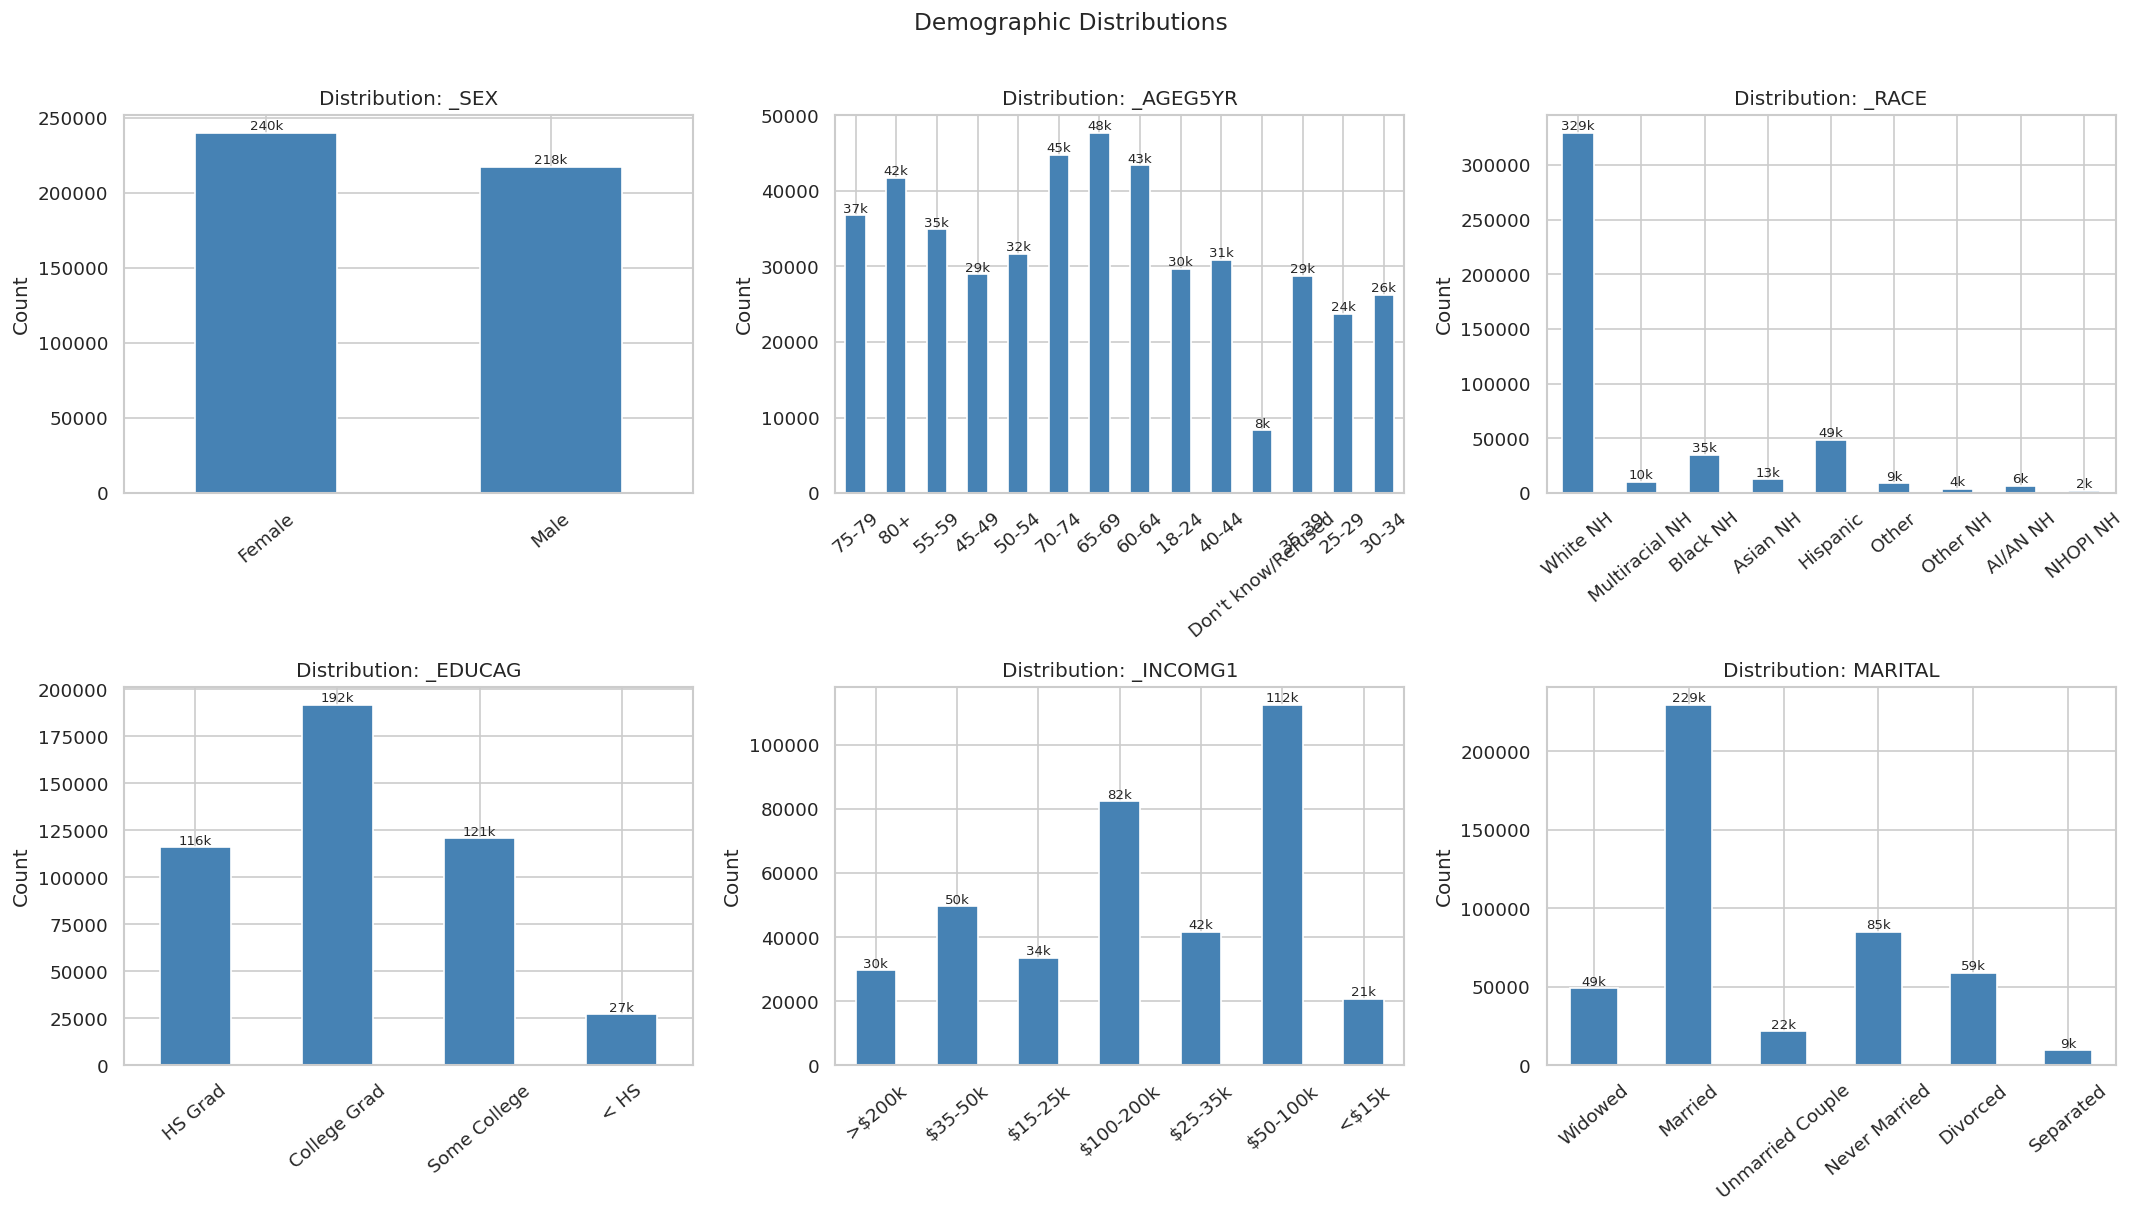

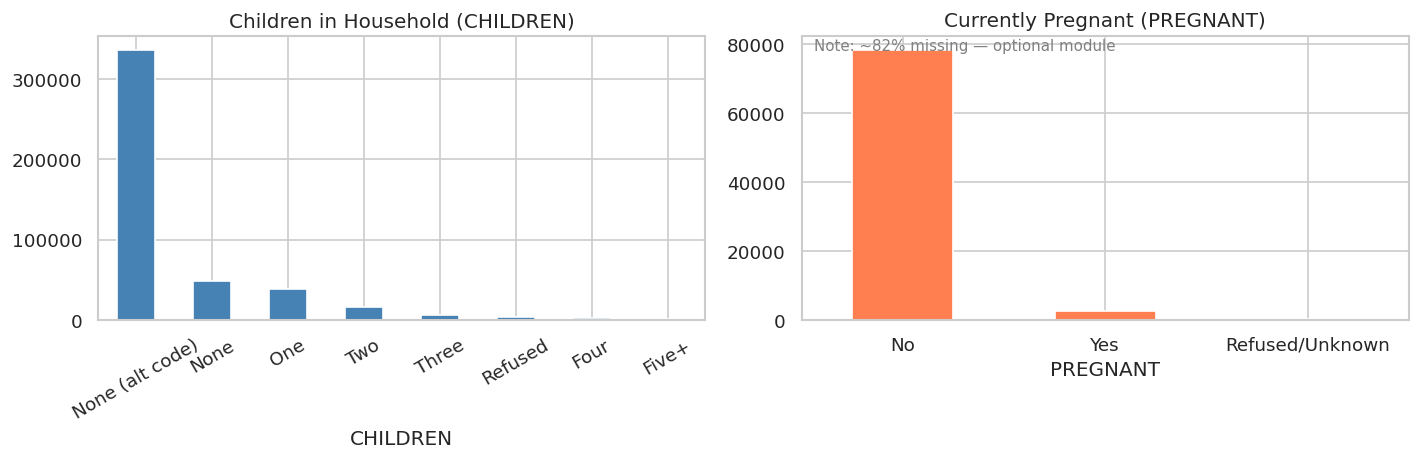

In [ ]:
# ── 4. Demographic distributions ─────────────────────────────
demo_labels = {
    '_SEX':     {1: 'Male', 2: 'Female'},
    '_AGEG5YR': {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
                 6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
                 11:'70-74',12:'75-79',13:'80+',14:"Don't know/Refused"},
    '_RACE':    {1:'White NH',2:'Black NH',3:'AI/AN NH',4:'Asian NH',
                 5:'NHOPI NH',6:'Other NH',7:'Multiracial NH',8:'Hispanic',9:'Other'},
    '_EDUCAG':  {1:'< HS',2:'HS Grad',3:'Some College',4:'College Grad'},
    '_INCOMG1': {1:'<$15k',2:'$15-25k',3:'$25-35k',4:'$35-50k',
                 5:'$50-100k',6:'$100-200k',7:'>$200k'},
    'MARITAL':  {1:'Married',2:'Divorced',3:'Widowed',4:'Separated',
                 5:'Never Married',6:'Unmarried Couple'},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, lbl_map) in enumerate(demo_labels.items()):
    ax = axes[i]
    counts = df[col].astype(float).map(lbl_map).value_counts(sort=False).dropna()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=40)
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/1000:.0f}k",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle("Demographic Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── 4b. Children in household & pregnancy (newly grouped vars) ─
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

children_map = {1:'None',2:'One',3:'Two',4:'Three',5:'Four',6:'Five+',
                88:'None (alt code)', 99:'Refused'}
children_counts = df['CHILDREN'].astype(float).map(children_map).value_counts()
children_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Children in Household (CHILDREN)")
axes[0].tick_params(axis='x', rotation=30)

pregnant_map = {1:'Yes', 2:'No', 9:'Refused/Unknown'}
preg_counts = df['PREGNANT'].astype(float).map(pregnant_map).value_counts()
preg_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title("Currently Pregnant (PREGNANT)")
axes[1].tick_params(axis='x', rotation=0)
axes[1].annotate("Note: ~82% missing — optional module", xy=(0.02, 0.95),
                 xycoords='axes fraction', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

* **Sex:** The sample is approximately 52% female and 48% male, consistent with
  BRFSS telephone recruitment patterns. Survey weights adjust for this modest skew,
  but sex should be included as a covariate in any outcome model rather than
  assumed balanced.

* **Age:** The distribution peaks around the 55–59 age group (bin 8, the median
  bin), with meaningful representation across all mid- and older-life groups.
  Adults 18–34 are underrepresented relative to the general population, which
  inflates cross-sectional chronic disease rates — age must be controlled in any
  outcome model.

* **Race/ethnicity:** ~70% of respondents are Non-Hispanic White. Hispanic and
  Asian subgroups are undercounted relative to Census proportions; subgroup
  estimates for these groups carry wider uncertainty and should be interpreted
  cautiously.

* **Education:** The sample skews toward Some College (code 3) and College Grad
  (code 4), with College Grads representing the largest single group. Less than
  high school is the smallest group. This overstates educational attainment
  relative to the US adult population and understates disease burden in
  lower-education groups where both prevalence and access barriers are highest.

* **Income:** The $50–100k bracket is the modal income group, consistent with
  the mean of 5.38 on the 1–7 income scale. Lower-income brackets (<$25k) are
  present but underrepresented relative to their share of the US adult population
  — a known BRFSS limitation that understates disease burden in the highest-risk
  income groups.

* **Marital status:** Married respondents are the plurality. Marital status
  correlates with both income stability and healthcare access and is included in
  DEMO_VARS for cross-tab use.

* **Children & pregnancy:** CHILDREN and PREGNANT are both in DEMO_VARS.
  PREGNANT is 82.2% missing (optional module, female respondents only) — it can
  be used for female-only subgroup analyses where available but should not enter
  any full-sample model.

## Section 5: Outcome (Chronic Disease) Prevalence

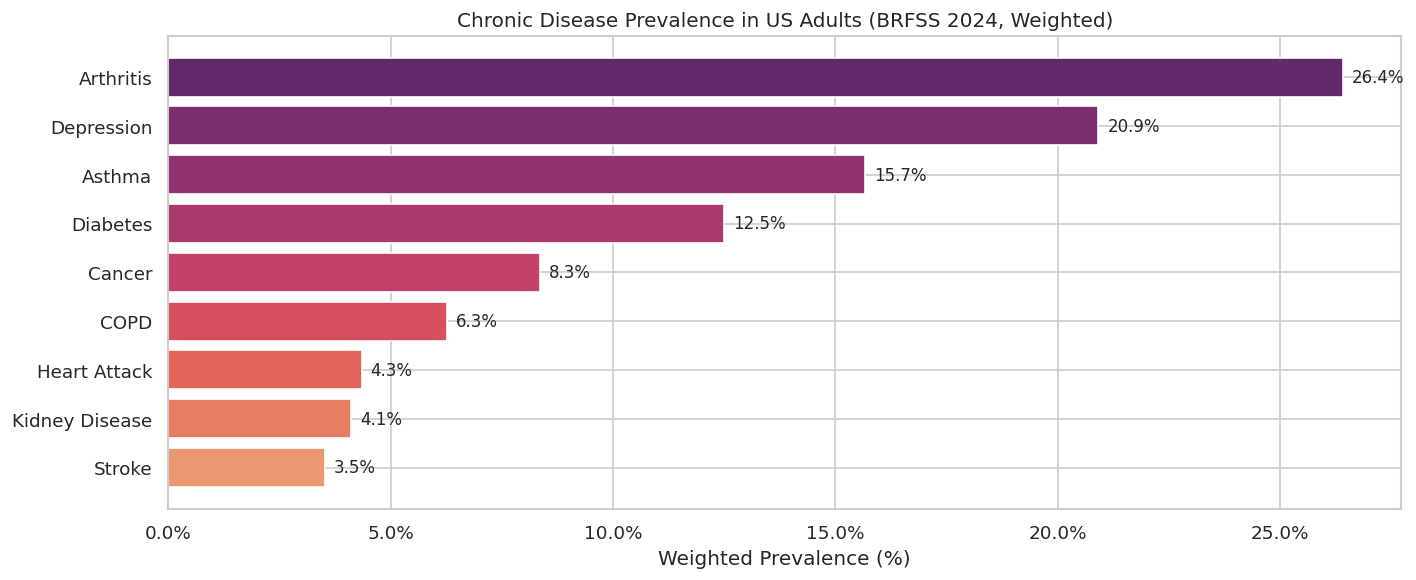

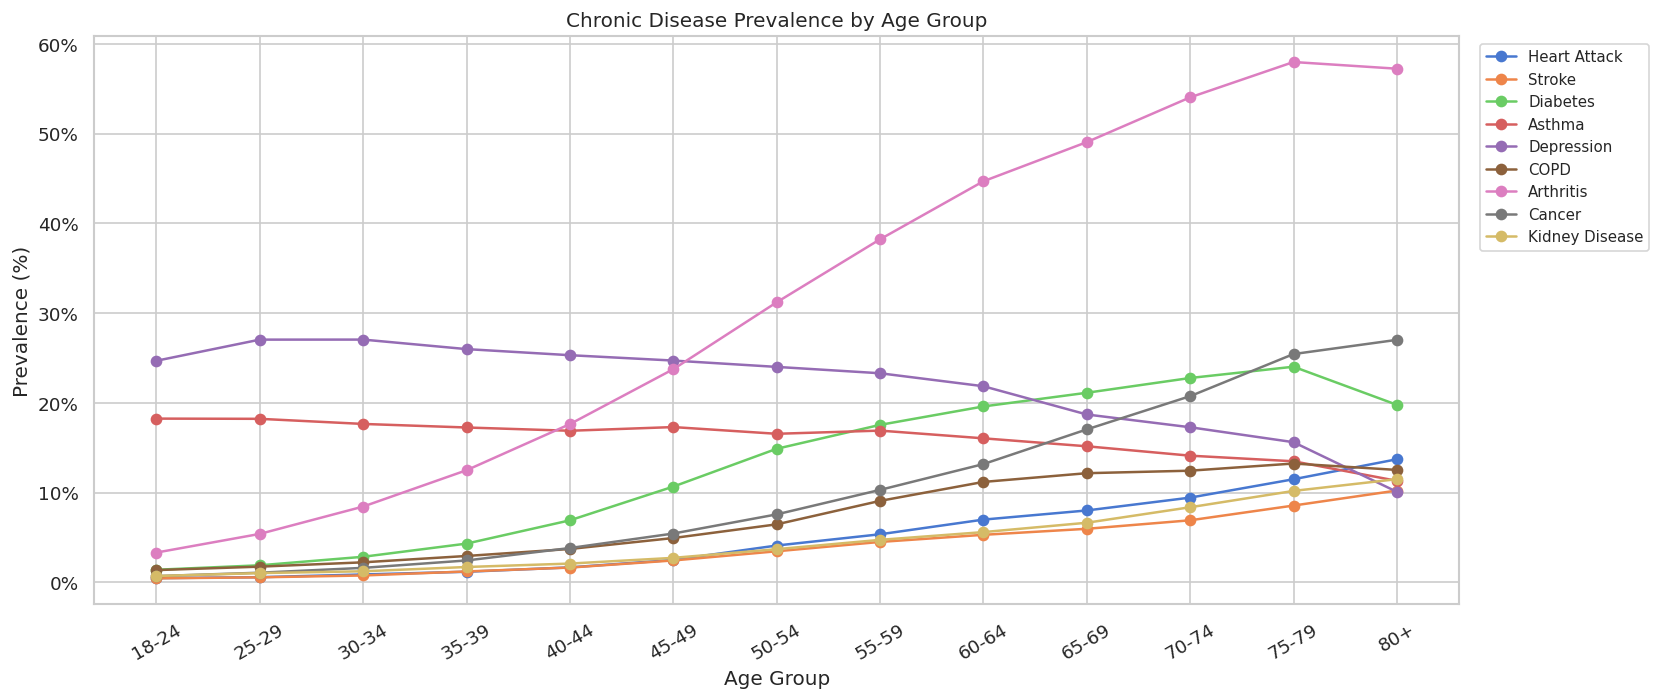

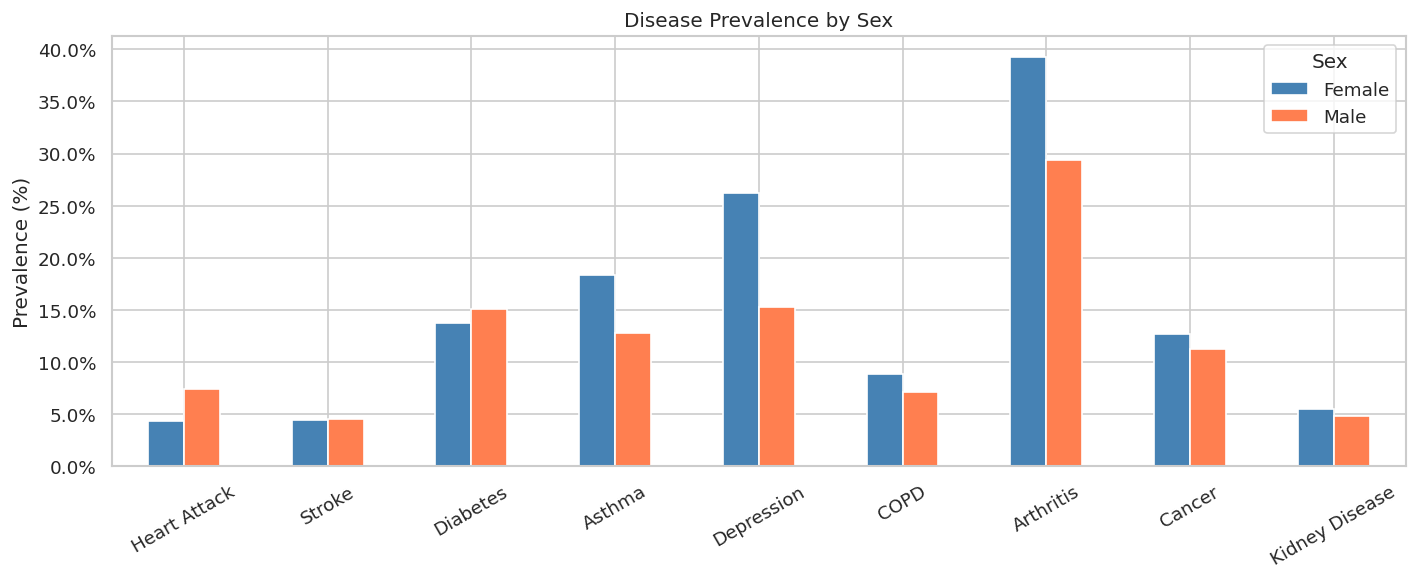

In [ ]:
# ── 5a. Overall weighted prevalence bar chart ─────────────────
fig, ax = plt.subplots(figsize=(12, 5))
prev_sorted = prev_df.sort_values('Weighted %')
colors = sns.color_palette("flare", len(prev_sorted))
bars = ax.barh(prev_sorted['Condition'], prev_sorted['Weighted %'], color=colors)
for bar, val in zip(bars, prev_sorted['Weighted %']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=10)
ax.set_xlabel("Weighted Prevalence (%)")
ax.set_title("Chronic Disease Prevalence in US Adults (BRFSS 2024, Weighted)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

# ── 5b. Prevalence by age group ───────────────────────────────
age_map = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
           6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
           11:'70-74',12:'75-79',13:'80+'}

age_prev = {}
for col, label in OUTCOME_LABELS.items():
    tmp = df[['_AGEG5YR', col]].copy()
    tmp[col] = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['age_label'] = tmp['_AGEG5YR'].astype(float).map(age_map)
    age_prev[label] = tmp.dropna().groupby('age_label')[col].mean() * 100

age_prev_df = pd.DataFrame(age_prev).reindex(
    [v for v in age_map.values() if v in pd.DataFrame(age_prev).index])

fig, ax = plt.subplots(figsize=(14, 6))
for col in age_prev_df.columns:
    ax.plot(age_prev_df.index, age_prev_df[col], marker='o', label=col)
ax.set_xlabel("Age Group")
ax.set_ylabel("Prevalence (%)")
ax.set_title("Chronic Disease Prevalence by Age Group")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ── 5c. Prevalence by sex ─────────────────────────────────────
sex_map = {1: 'Male', 2: 'Female'}
sex_prev = {}
for col, label in OUTCOME_LABELS.items():
    tmp = df[['_SEX', col]].copy()
    tmp[col] = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['sex'] = tmp['_SEX'].astype(float).map(sex_map)
    sex_prev[label] = tmp.dropna().groupby('sex')[col].mean() * 100

sex_df = pd.DataFrame(sex_prev)
fig, ax = plt.subplots(figsize=(12, 5))
sex_df.T.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
ax.set_title("Disease Prevalence by Sex")
ax.set_ylabel("Prevalence (%)")
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Sex')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

* Arthritis is the most prevalent condition at 26.4% (weighted), followed by Depression (20.9%), Asthma (15.7%), and Diabetes (12.5%).
* Prevalence rises sharply and consistently with age across all nine conditions. Arthritis and Heart Attack show the steepest age gradients; Depression is notably flatter, with meaningful prevalence even in the 18–34 group.
* Heart Attack (4.4%) and Stroke (3.5%) are the lowest-prevalence conditions but represent the highest-acuity outcomes. They should anchor any "high-risk" cluster definition despite their lower base rates.
* Cancer (8.4% weighted vs. 12.0% unweighted) shows the largest weighting correction of any outcome, underscoring that the raw sample over-represents older, cancer-prevalent respondents.
* Sex differences are present but condition-specific: Arthritis and Depression skew female; Heart Attack and COPD skew male. Sex should be included as a covariate rather than used as a stratification variable given sample imbalance.

## Section 6: Behavioral Risk Factors

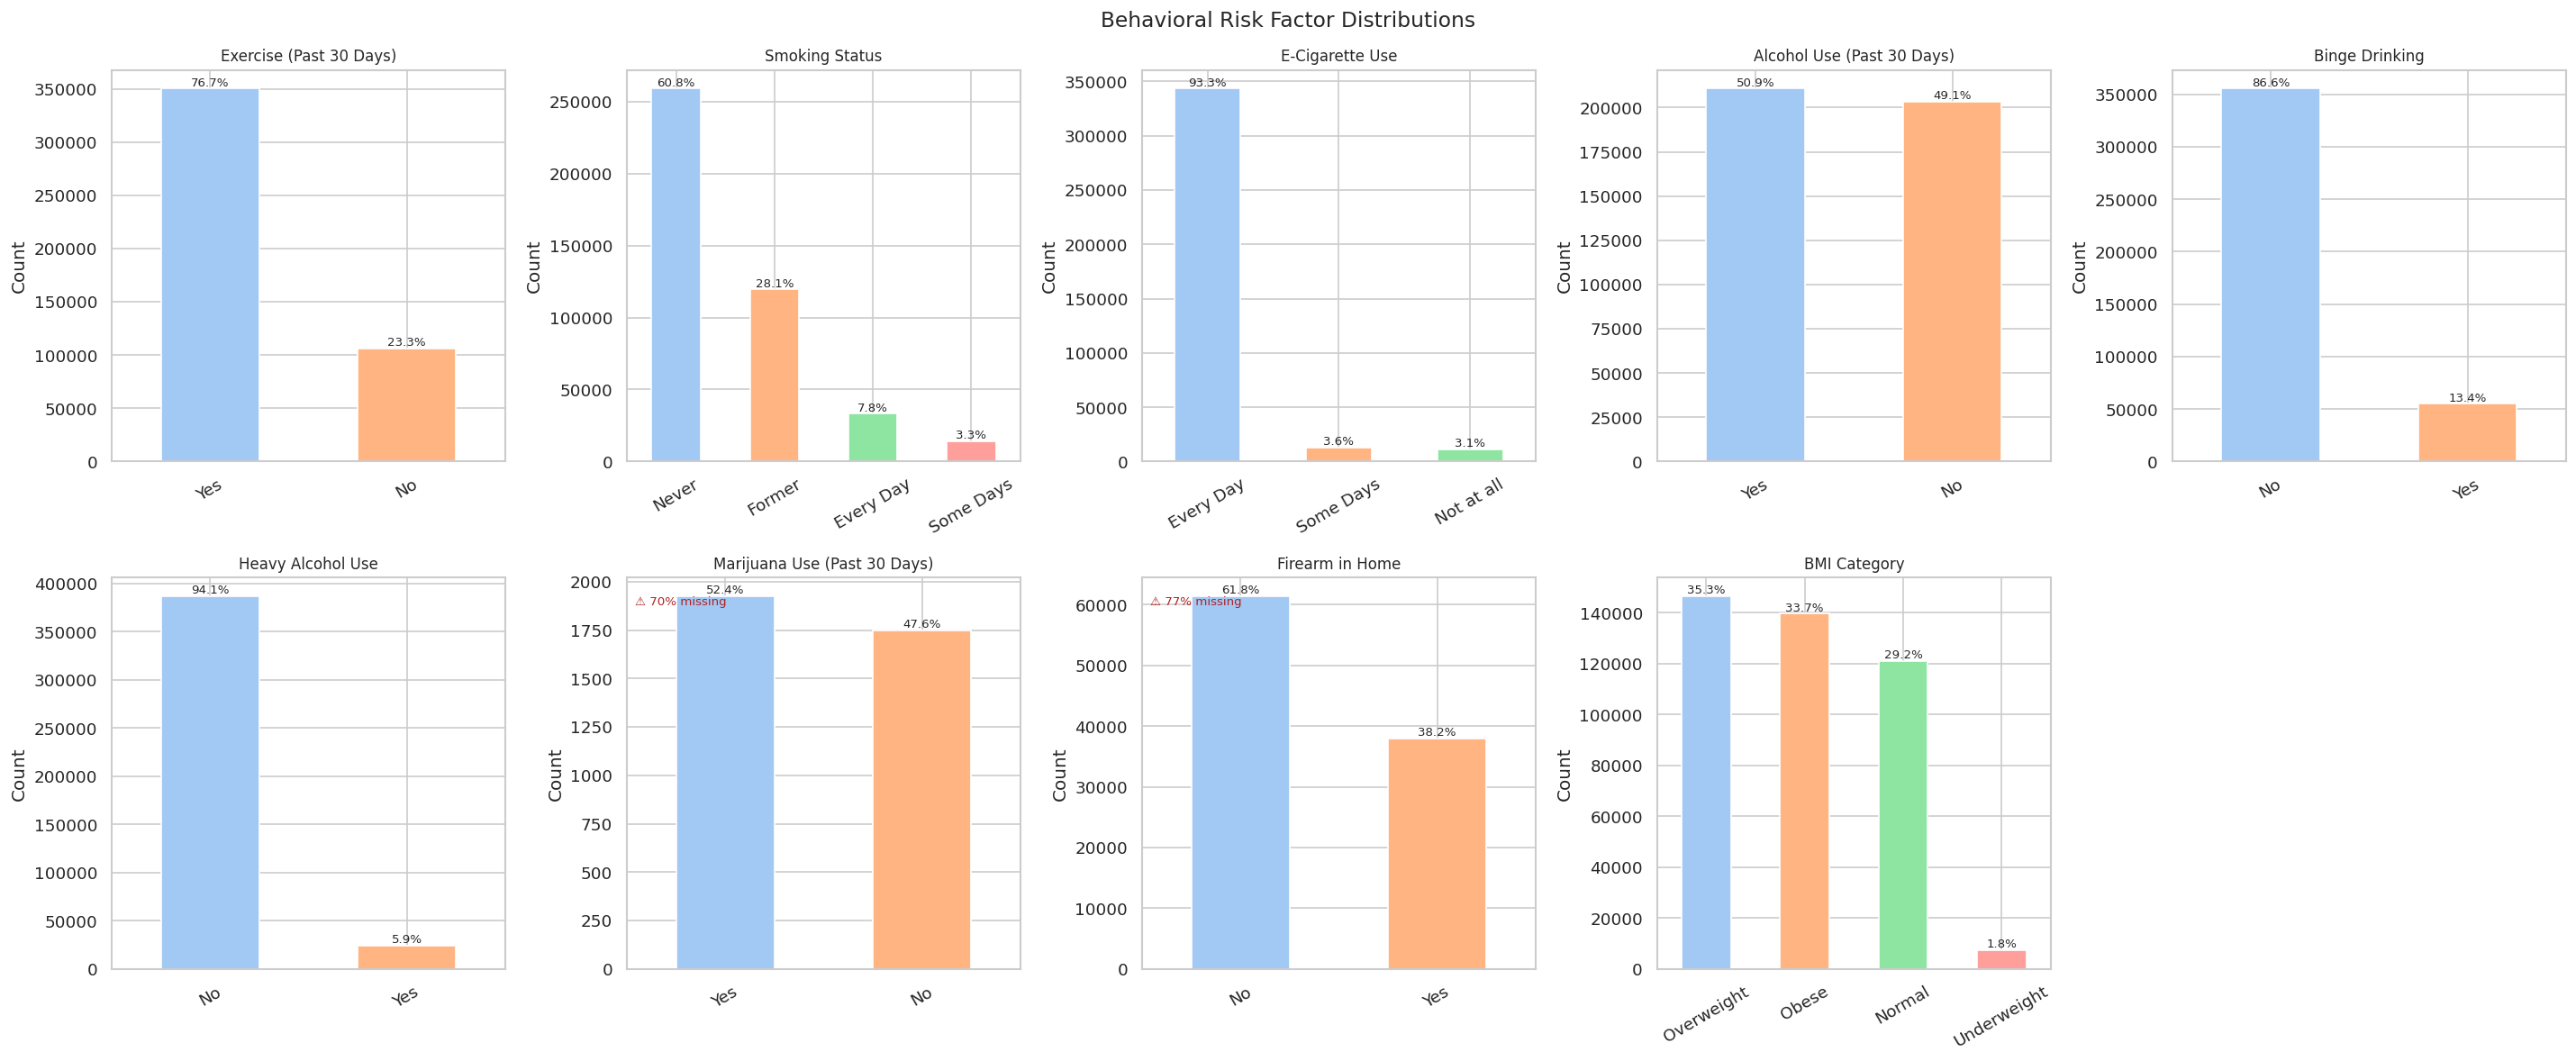

In [ ]:
# ── 6a. Behavioral variable distributions ────────────────────
behavior_labels = {
    'EXERANY2':  ({1:'Yes', 2:'No'},                              'Exercise (Past 30 Days)'),
    '_SMOKER3':  ({1:'Every Day',2:'Some Days',3:'Former',4:'Never'}, 'Smoking Status'),
    'ECIGNOW3':  ({1:'Every Day',2:'Some Days',3:'Not at all'},   'E-Cigarette Use'),
    'DRNKANY6':  ({1:'Yes', 2:'No'},                              'Alcohol Use (Past 30 Days)'),
    '_RFBING6':  ({1:'No', 2:'Yes'},                              'Binge Drinking'),
    '_RFDRHV9':  ({1:'No', 2:'Yes'},                              'Heavy Alcohol Use'),
    'MARIJAN1':  ({1:'Yes', 2:'No'},                              'Marijuana Use (Past 30 Days)'),
    'SSBSUGR2':  ({1:'Once/day+',2:'1-6x/week',3:'Less than weekly',4:'Never'}, 'Sugary Drink Frequency'),
    'FIREARM5':  ({1:'Yes', 2:'No'},                              'Firearm in Home'),
    '_BMI5CAT':  ({1:'Underweight',2:'Normal',3:'Overweight',4:'Obese'}, 'BMI Category'),
}

fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()
plot_idx = 0

for col, (lbl_map, title) in behavior_labels.items():
    counts = df[col].astype(float).map(lbl_map).value_counts().dropna()
    if counts.empty:
        continue  # skip columns with no mappable values

    ax = axes[plot_idx]
    plot_idx += 1

    counts.plot(kind='bar', ax=ax,
                color=sns.color_palette("pastel", len(counts)), edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    total = counts.sum()
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/total*100:.1f}%",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

    miss_pct = df[col].isnull().mean() * 100
    if miss_pct > 30:
        ax.annotate(f"⚠ {miss_pct:.0f}% missing", xy=(0.02, 0.93),
                    xycoords='axes fraction', fontsize=8, color='firebrick')

for j in range(plot_idx, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Behavioral Risk Factor Distributions", fontsize=14)
plt.tight_layout()
plt.show()

* ~74% report exercising in the past 30 days (EXERANY2). Given self-report bias
  and the broad definition ("any exercise"), this likely overstates true physical
  activity.

* 14% are current smokers (daily or some days); 57% never smoked. The former
  smoker group (~29%) is analytically important — their disease rates fall
  consistently between current and never smokers, useful for dose-response
  analysis.

* ~65% of respondents fall into overweight or obese BMI categories combined,
  making BMI the most universally distributed modifiable risk factor in the
  dataset.

* MARIJAN1, SSBSUGR2, and FIREARM5 are 70–77% missing due to optional state
  administration — the distributions shown reflect only the states that opted in
  and are not nationally representative. Flag these in any regression that
  includes them.

* AVEDRNK4 is 54.1% missing because it routes only to current drinkers and is
  not plotted in this section. Its distribution among drinkers should be assessed
  separately before including it in any model; among those with valid responses it
  is expected to show a strong right skew.

* Binge drinking (_RFBING6) and heavy drinking (_RFDRHV9) have low overall
  prevalence but are concentrated in younger age groups, making them more relevant
  for younger-cohort analyses than for the full sample.

## Section 7: Healthcare Access


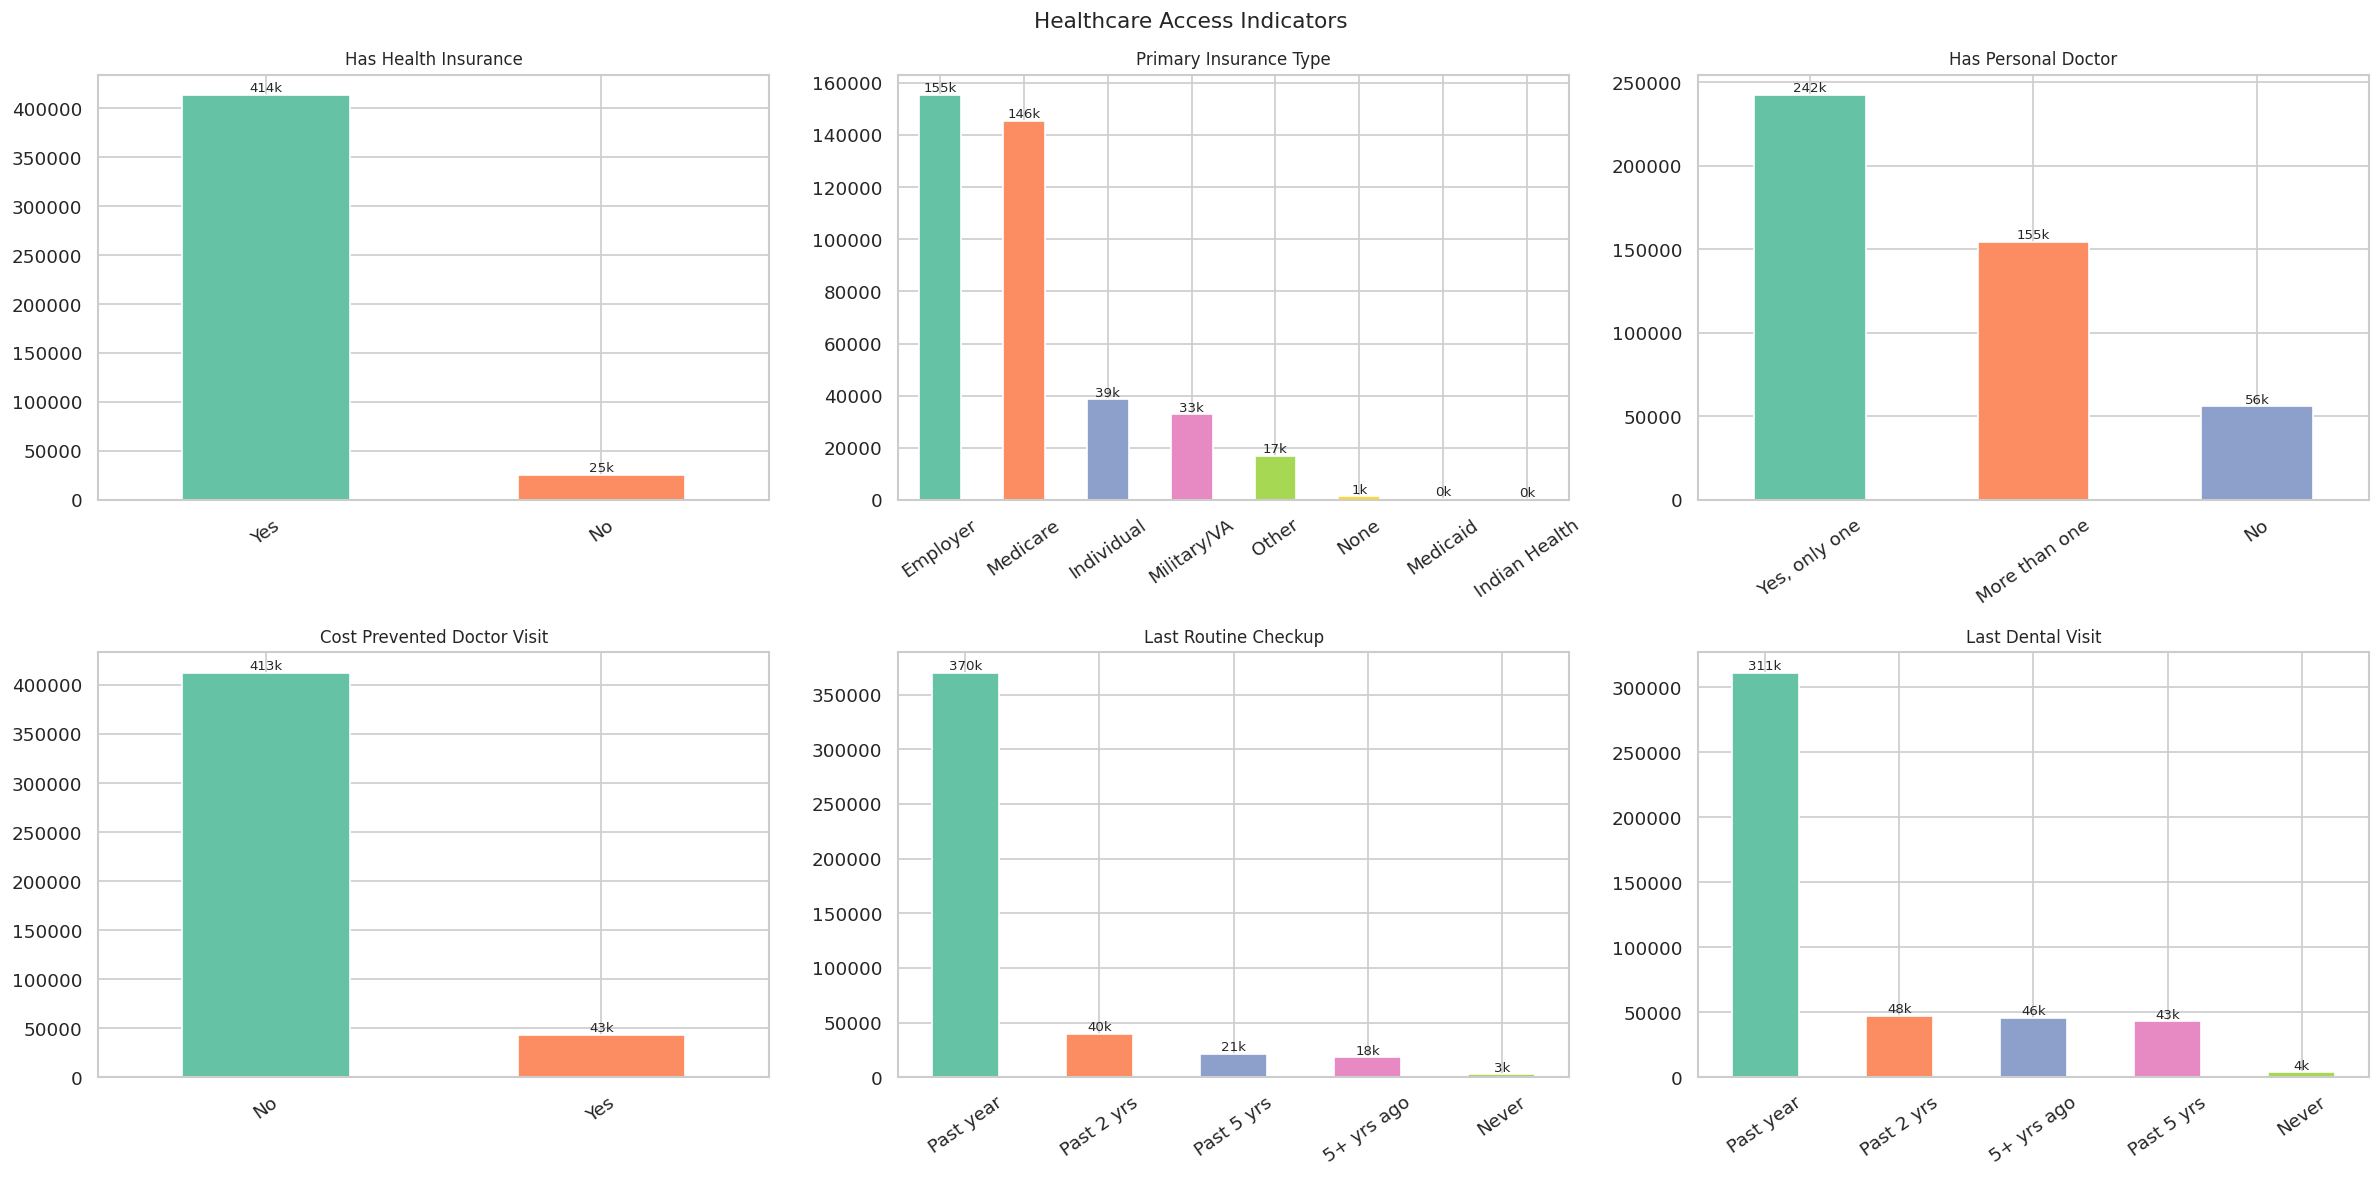

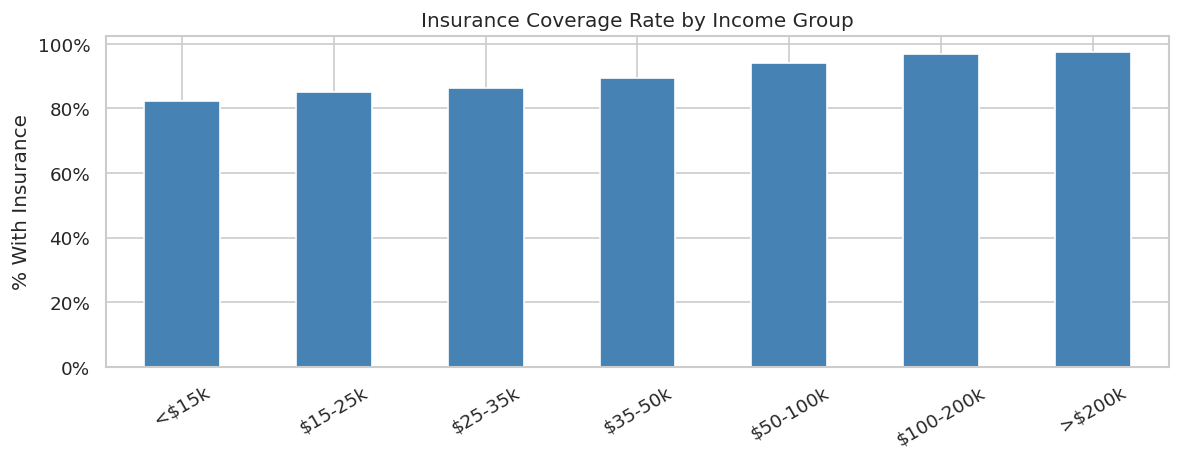

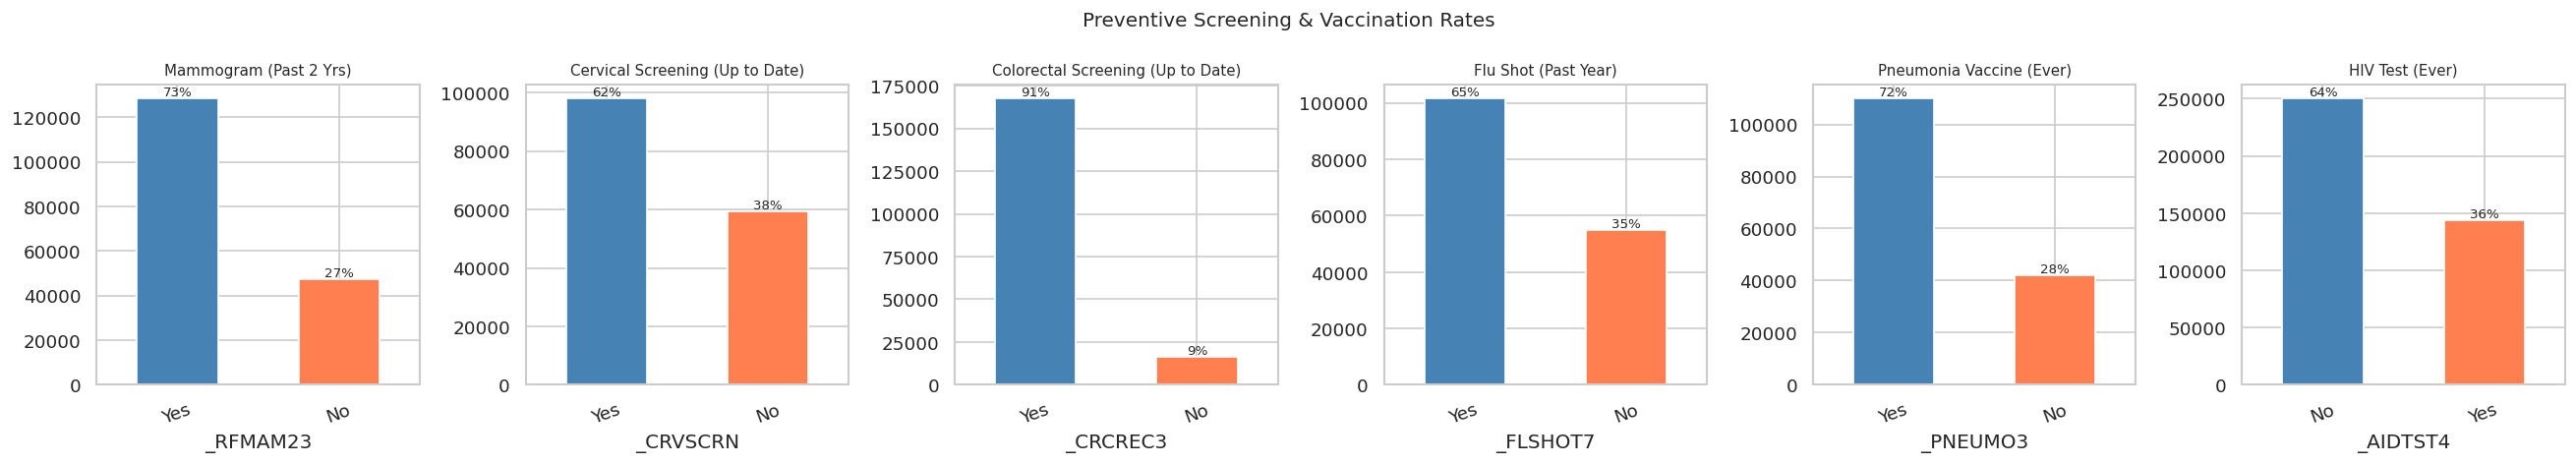

In [ ]:
# ── 7a. Access indicator distributions ───────────────────────
access_labels = {
    '_HLTHPL2': ({1:'Yes', 2:'No'},                                        'Has Health Insurance'),
    'PRIMINS2': ({1:'Employer',2:'Individual',3:'Medicare',4:'Medicaid',
                  5:'Military/VA',6:'Indian Health',7:'Other',8:'None'}, 'Primary Insurance Type'),
    'PERSDOC3': ({1:'Yes, only one',2:'More than one',3:'No'},             'Has Personal Doctor'),
    'MEDCOST1': ({1:'Yes', 2:'No'},                                        'Cost Prevented Doctor Visit'),
    'CHECKUP1': ({1:'Past year',2:'Past 2 yrs',3:'Past 5 yrs',
                  4:'5+ yrs ago',8:'Never'},                               'Last Routine Checkup'),
    'LASTDEN4': ({1:'Past year',2:'Past 2 yrs',3:'Past 5 yrs',
                  4:'5+ yrs ago',8:'Never'},                               'Last Dental Visit'),
}

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, (col, (lbl_map, title)) in enumerate(access_labels.items()):
    ax = axes[i]
    counts = df[col].astype(float).map(lbl_map).value_counts().dropna()
    counts.plot(kind='bar', ax=ax,
                color=sns.color_palette("Set2", len(counts)), edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=35)
    total = counts.sum()
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/1000:.0f}k",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle("Healthcare Access Indicators", fontsize=13)
plt.tight_layout()
plt.show()

# ── 7b. Insurance coverage rate by income group ───────────────
income_map = {1:'<$15k',2:'$15-25k',3:'$25-35k',4:'$35-50k',
              5:'$50-100k',6:'$100-200k',7:'>$200k'}

tmp = df[['_INCOMG1', '_HLTHPL2']].copy()
tmp['has_ins'] = (tmp['_HLTHPL2'].astype(float) == 1).astype(float)
tmp['income']  = tmp['_INCOMG1'].astype(float).map(income_map)
ins_by_income  = tmp.dropna().groupby('income')['has_ins'].mean() * 100
ins_by_income  = ins_by_income.reindex([v for v in income_map.values() if v in ins_by_income.index])

fig, ax = plt.subplots(figsize=(10, 4))
ins_by_income.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title("Insurance Coverage Rate by Income Group")
ax.set_ylabel("% With Insurance")
ax.set_xlabel("")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# ── 7c. Prevention screenings (new group) ────────────────────
prevention_labels = {
    '_RFMAM23': ({1:'Yes', 2:'No'}, 'Mammogram (Past 2 Yrs)'),
    '_CRVSCRN': ({1:'Yes', 2:'No'}, 'Cervical Screening (Up to Date)'),
    '_CRCREC3': ({1:'Yes', 2:'No'}, 'Colorectal Screening (Up to Date)'),
    '_FLSHOT7': ({1:'Yes', 2:'No'}, 'Flu Shot (Past Year)'),
    '_PNEUMO3': ({1:'Yes', 2:'No'}, 'Pneumonia Vaccine (Ever)'),
    '_AIDTST4': ({1:'Yes', 2:'No'}, 'HIV Test (Ever)'),
}

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for i, (col, (lbl_map, title)) in enumerate(prevention_labels.items()):
    ax = axes[i]
    counts = df[col].astype(float).map(lbl_map).value_counts().dropna()
    counts.plot(kind='bar', ax=ax,
                color=['steelblue','coral'][:len(counts)], edgecolor='white')
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis='x', rotation=20)
    total = counts.sum()
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/total*100:.0f}%",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle("Preventive Screening & Vaccination Rates", fontsize=12)
plt.tight_layout()
plt.show()

* ~93% report having health insurance (_HLTHPL2), but coverage drops sharply in the lowest income brackets — uninsured rates are meaningfully higher at <$15k and $15–25k, confirming that income, not just employment, drives the coverage gap.
* Employer-sponsored insurance is the dominant primary insurance type (PRIMINS2), followed by Medicare, reflecting the sample's older age skew.
* Cost as a barrier (MEDCOST1) and lack of a personal doctor (PERSDOC3) co-cluster at lower income levels, indicating that the preventive care gap is income-driven, not solely insurance-driven.
* Most respondents had a routine checkup in the past year (CHECKUP1), though a non-trivial share report 5+ years or never — these are likely the highest-risk group for undiagnosed conditions.
* Dental access (LASTDEN4, newly in HEALTHCARE_VARS) follows a similar income gradient to medical access and is a useful proxy for overall preventive care engagement.
* Prevention screenings (PREVENTION_VARS) are 50–61% missing — state-optional. Among respondents with data, flu shot uptake is higher than pneumonia vaccine uptake, consistent with national CDC figures. HIV testing rates are lower, concentrated in younger respondents.

## Section 8: Geographic (State-Level) Profiles

Top 10 states by respondent count:


,fips,count,state
0,36.0,43913,NY
1,53.0,25800,WA
2,27.0,15199,MN
3,24.0,14462,MD
4,55.0,13096,WI
5,12.0,13086,FL
6,18.0,13050,IN
7,49.0,12782,UT
8,31.0,12671,NE
9,48.0,12291,TX


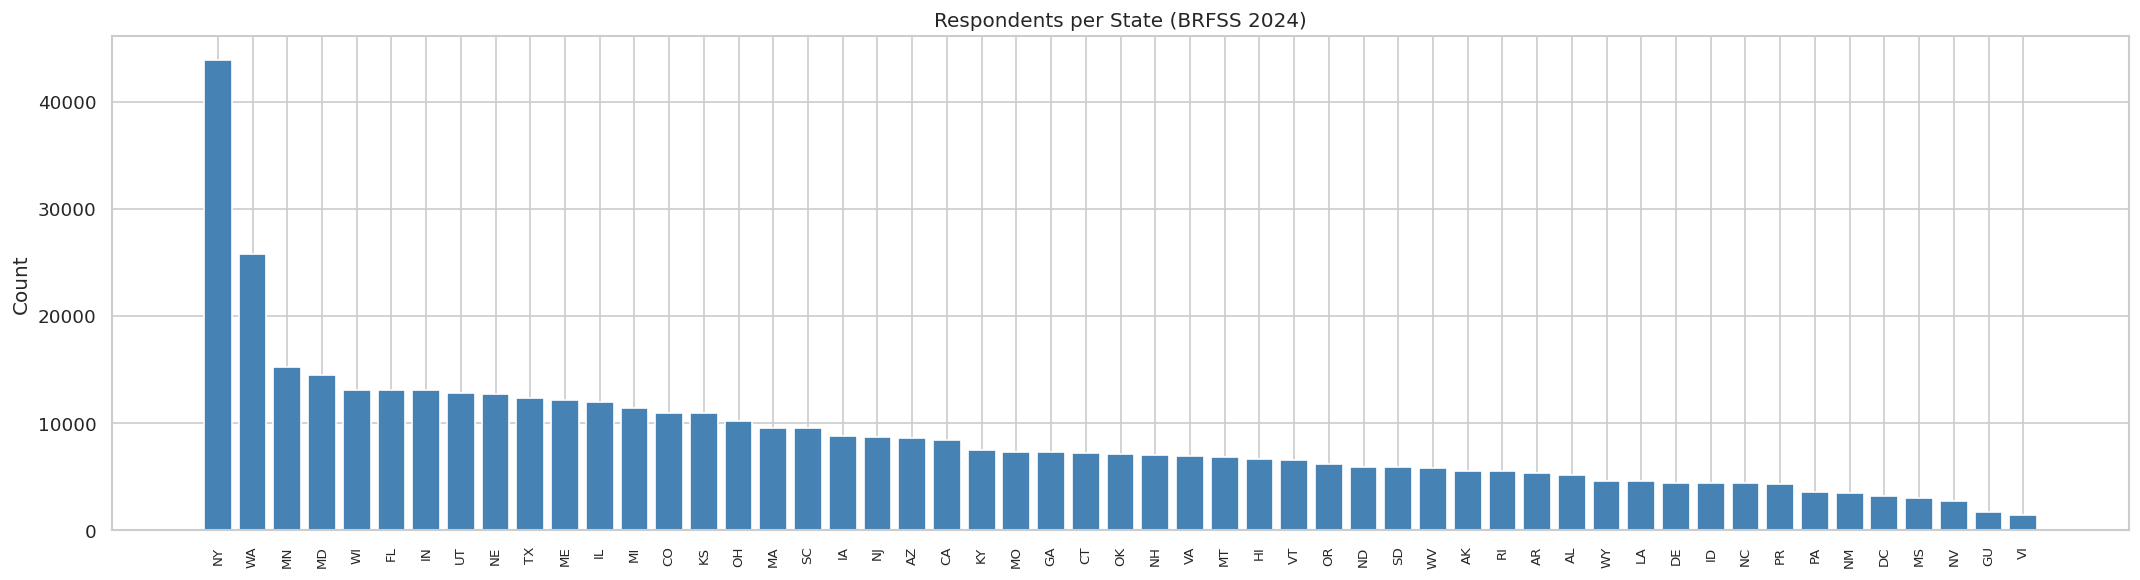

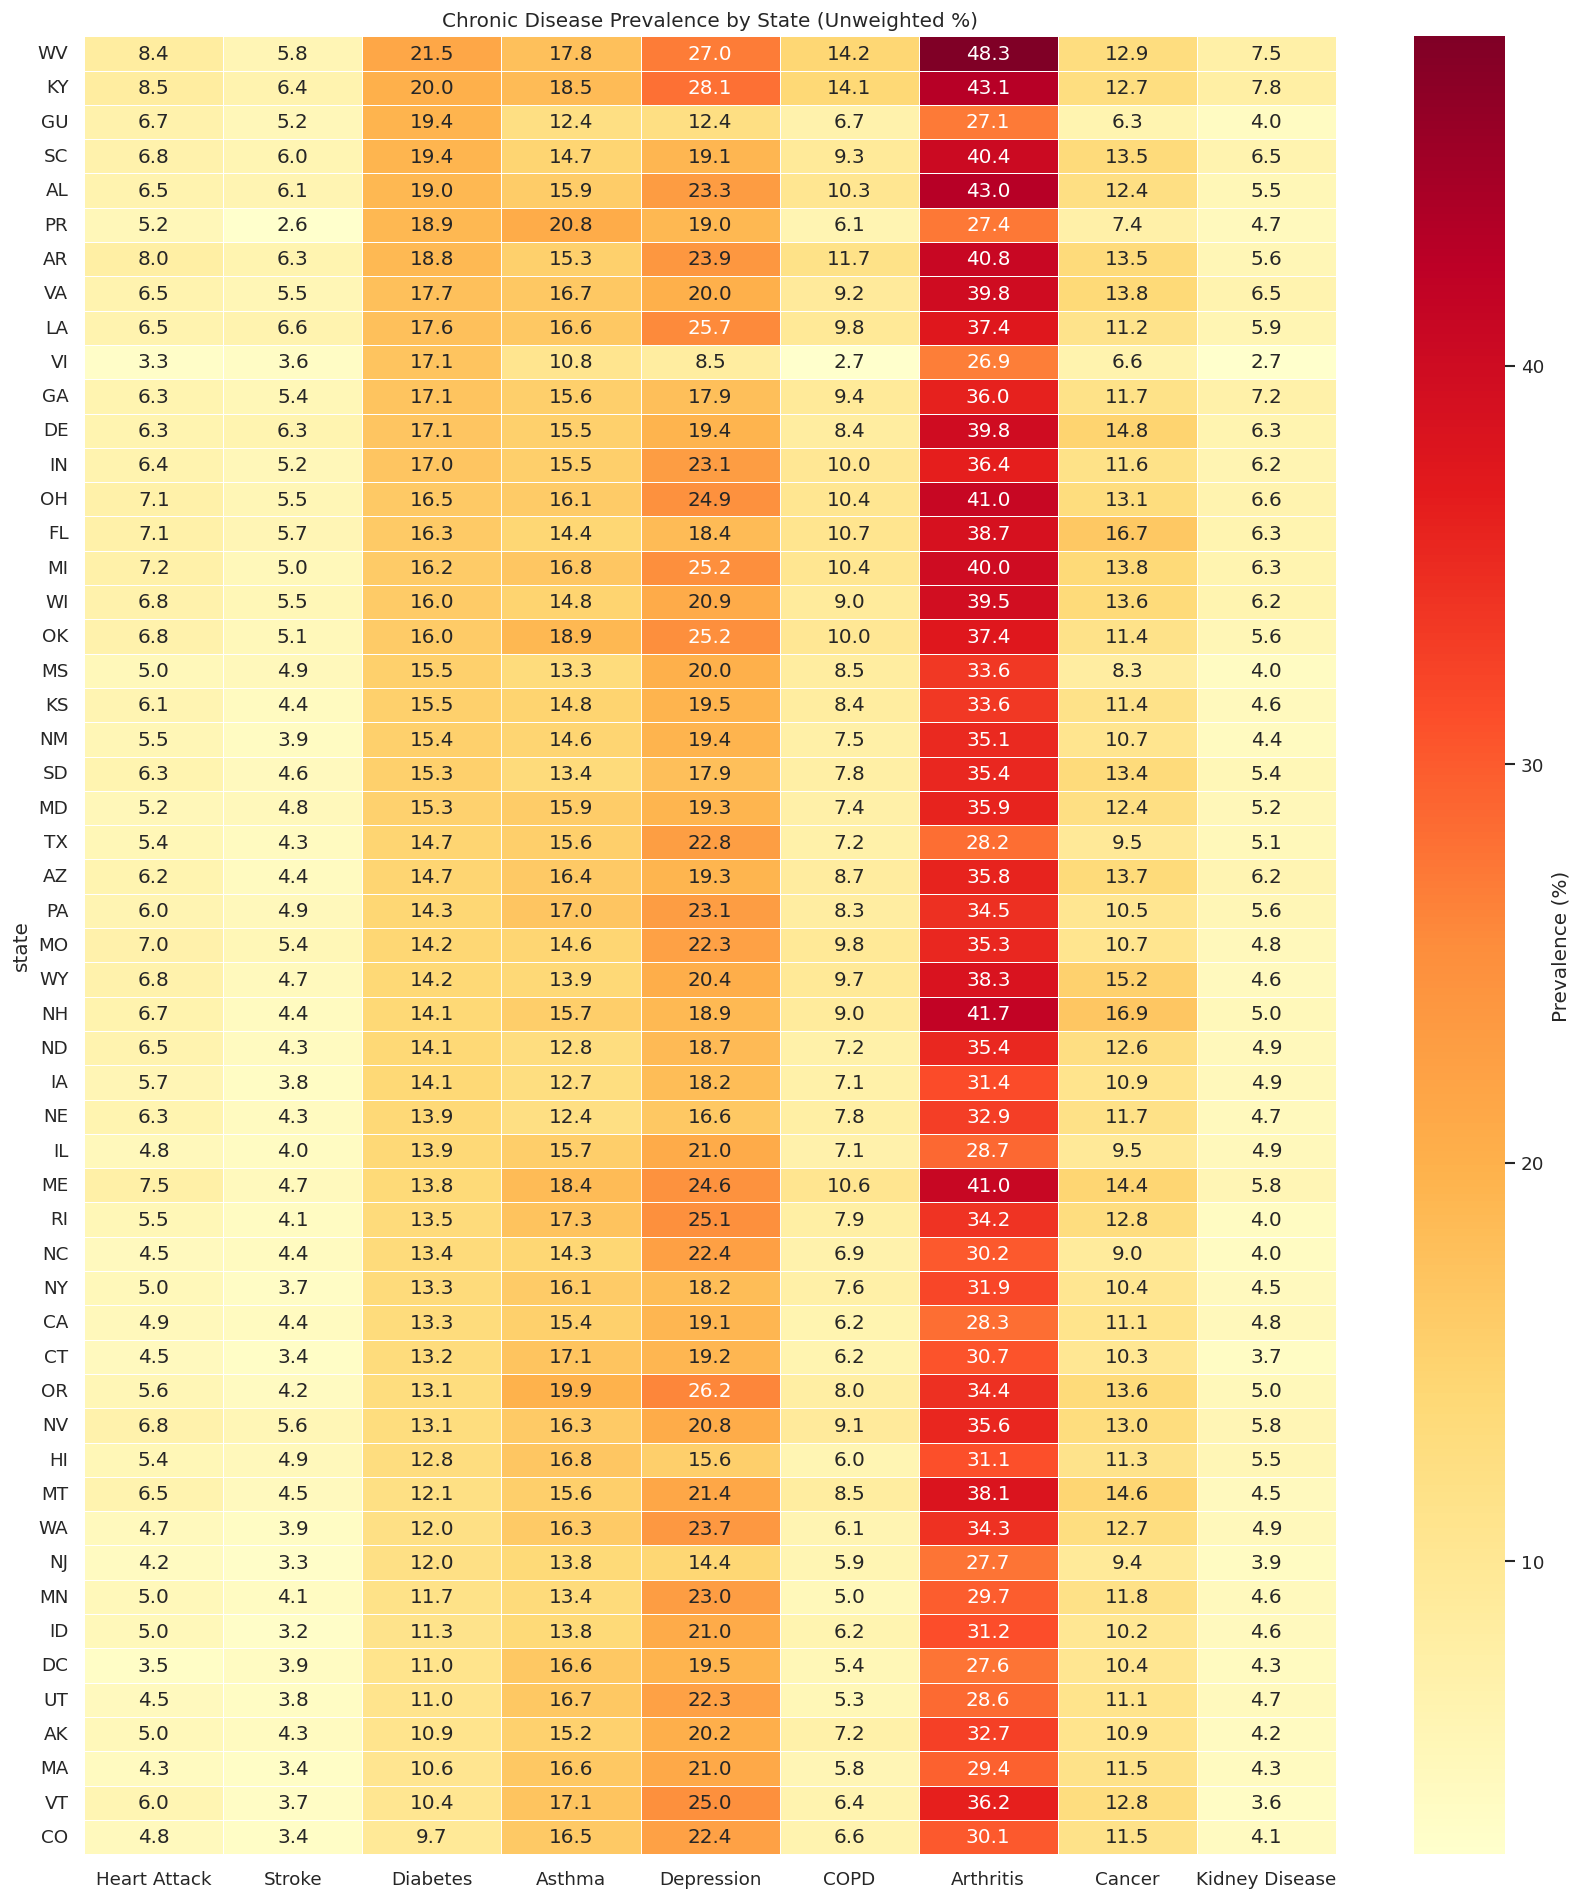

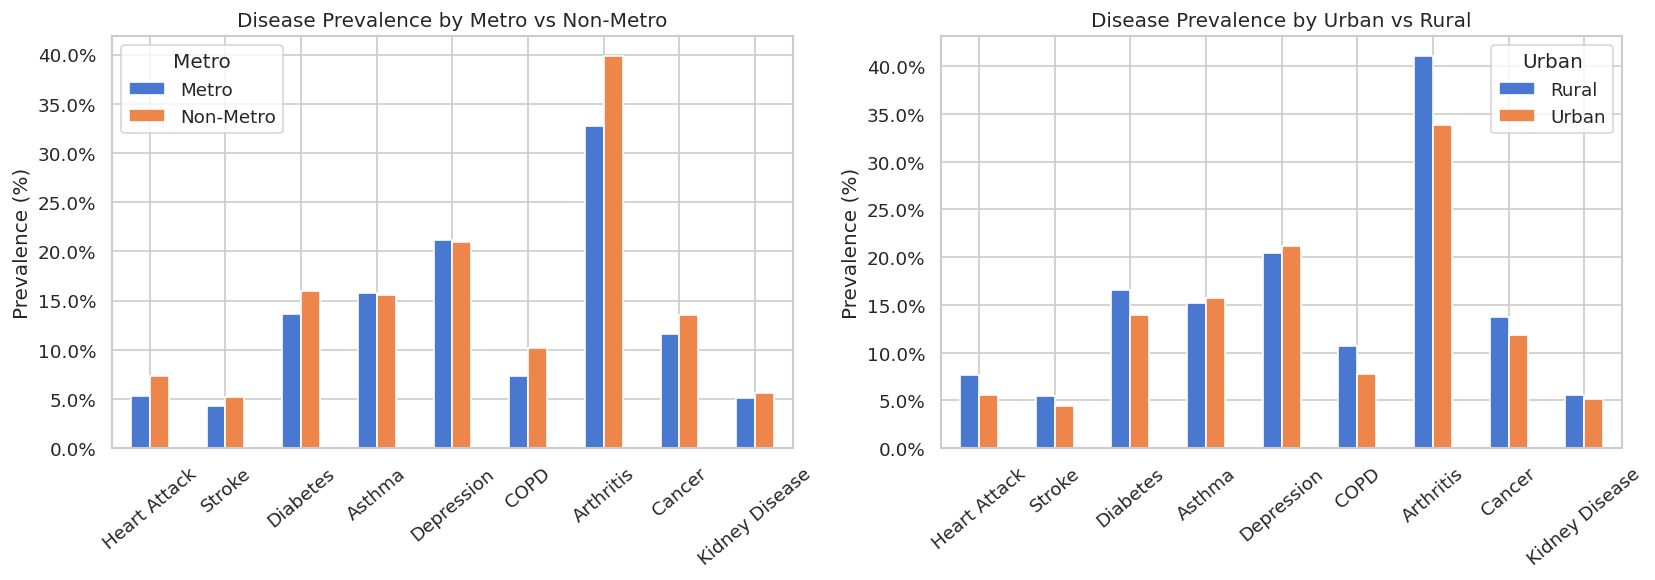

In [ ]:
# ── 8. State-level profiles ───────────────────────────────────
fips_to_state = {
    1:'AL',2:'AK',4:'AZ',5:'AR',6:'CA',8:'CO',9:'CT',10:'DE',
    11:'DC',12:'FL',13:'GA',15:'HI',16:'ID',17:'IL',18:'IN',
    19:'IA',20:'KS',21:'KY',22:'LA',23:'ME',24:'MD',25:'MA',
    26:'MI',27:'MN',28:'MS',29:'MO',30:'MT',31:'NE',32:'NV',
    33:'NH',34:'NJ',35:'NM',36:'NY',37:'NC',38:'ND',39:'OH',
    40:'OK',41:'OR',42:'PA',44:'RI',45:'SC',46:'SD',47:'TN',
    48:'TX',49:'UT',50:'VT',51:'VA',53:'WA',54:'WV',55:'WI',
    56:'WY',66:'GU',72:'PR',78:'VI'
}

state_counts = df['_STATE'].astype(float).value_counts().reset_index()
state_counts.columns = ['fips', 'count']
state_counts['state'] = state_counts['fips'].map(fips_to_state)
state_counts = state_counts.sort_values('count', ascending=False)

print("Top 10 states by respondent count:")
display(state_counts.head(10))

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(state_counts['state'], state_counts['count'],
       color='steelblue', edgecolor='white', width=0.8)
ax.set_title("Respondents per State (BRFSS 2024)")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=90, labelsize=8)
plt.tight_layout()
plt.show()

# ── 8b. State heatmap: all outcomes ──────────────────────────
state_out = {}
for col, label in OUTCOME_LABELS.items():
    tmp = df[['_STATE', col]].copy()
    tmp[col]   = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['state'] = tmp['_STATE'].astype(float).map(fips_to_state)
    state_out[label] = tmp.dropna().groupby('state')[col].mean() * 100

state_out_df = pd.DataFrame(state_out)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(state_out_df.sort_values('Diabetes', ascending=False),
            annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={'label':'Prevalence (%)'})
ax.set_title("Chronic Disease Prevalence by State (Unweighted %)")
plt.tight_layout()
plt.show()

# ── 8c. Metro vs rural breakdown (new GEO_VARS) ───────────────
metstat_map = {1: 'Metro', 2: 'Non-Metro'}
urbstat_map  = {1: 'Urban', 2: 'Rural'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, lbl_map, title in zip(
    axes,
    ['_METSTAT', '_URBSTAT'],
    [metstat_map, urbstat_map],
    ['Metro vs Non-Metro', 'Urban vs Rural']
):
    out_prev = {}
    for oc, label in OUTCOME_LABELS.items():
        tmp = df[[col, oc]].copy()
        tmp[oc]     = (tmp[oc].astype(float) == YES_CODE).astype(float)
        tmp['grp']  = tmp[col].astype(float).map(lbl_map)
        out_prev[label] = tmp.dropna().groupby('grp')[oc].mean() * 100

    grp_df = pd.DataFrame(out_prev)
    grp_df.T.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f"Disease Prevalence by {title}")
    ax.set_ylabel("Prevalence (%)")
    ax.tick_params(axis='x', rotation=40)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend(title=title.split()[0])

plt.tight_layout()
plt.show()

* New York is the largest contributor by far (43,913 respondents), followed by
  Washington (25,800), Minnesota (15,199), Maryland (14,462), and Wisconsin
  (13,096). Estimates for high-count states will be substantially more stable than
  for smaller-count states like Wyoming or Alaska.

* Southern states (MS, WV, AL, LA) show the highest unweighted diabetes
  prevalence; Colorado, Utah, and Hawaii the lowest — consistent with CDC
  surveillance data, likely reflecting compounding effects of income, obesity
  rates, and healthcare access. Note these are unweighted state-level figures and
  should not be cited as population-representative rates without applying survey
  weights.

* The state-level outcome heatmap reveals that disease co-occurrence is
  geographically clustered: states with high diabetes rates also tend to have high
  heart attack, COPD, and kidney disease rates, pointing toward shared upstream
  determinants (poverty, rurality, diet) rather than independent state effects.

* Metro vs. non-metro differences (_METSTAT) are consistent across all nine
  outcomes — non-metro respondents show higher prevalence for nearly every
  condition, most pronounced for COPD, Diabetes, and Arthritis.

* The rural/urban split (_URBSTAT) mirrors the metro/non-metro pattern,
  confirming that geography is a meaningful stratifier and should be included as a
  covariate or used to define subgroups in state-level models.

## Section 9: Correlation & Co-Occurrence

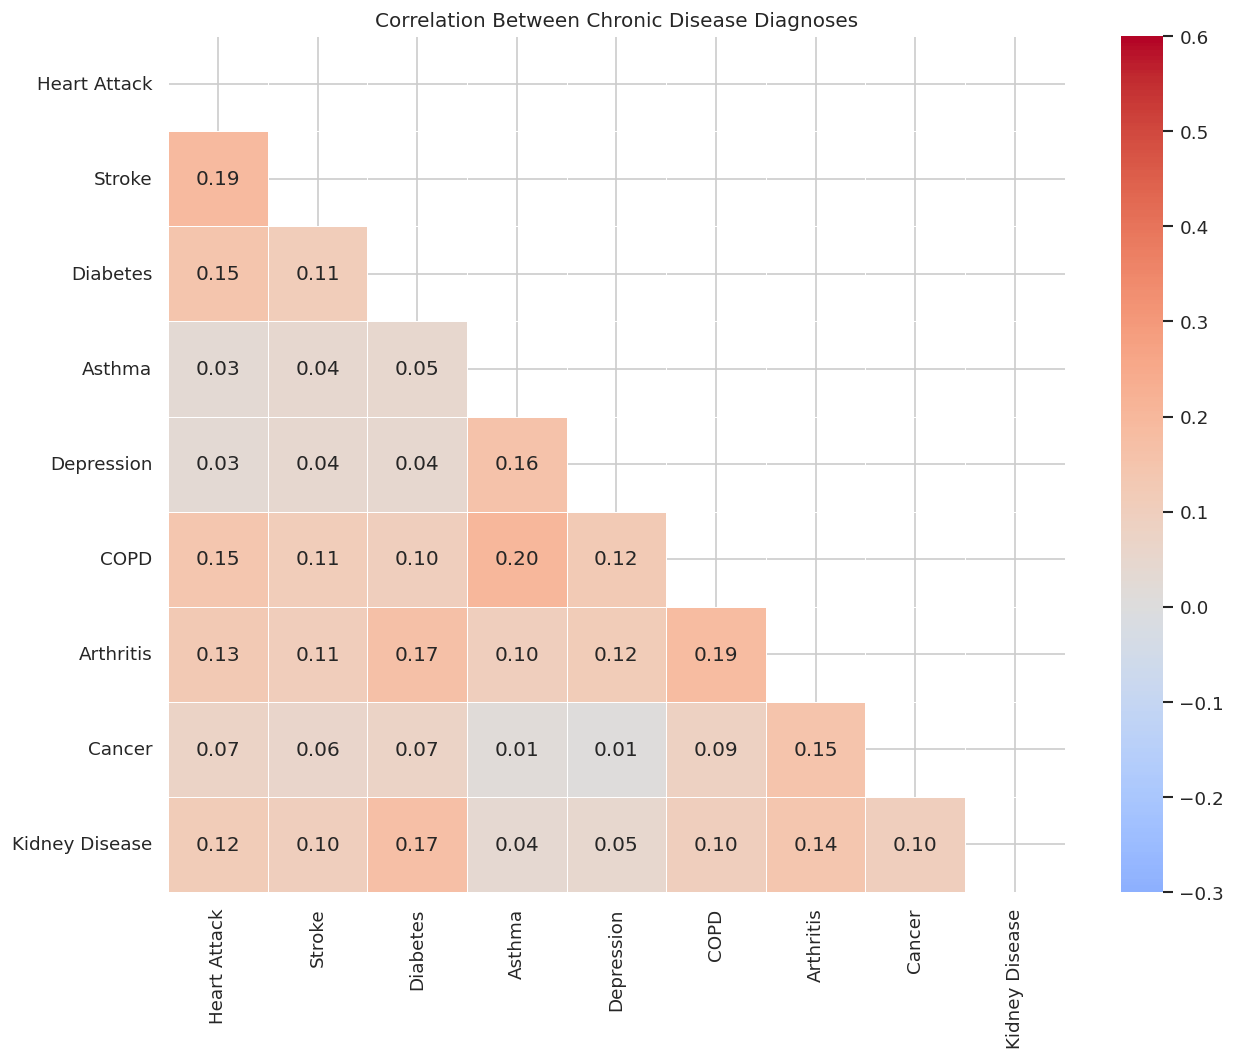

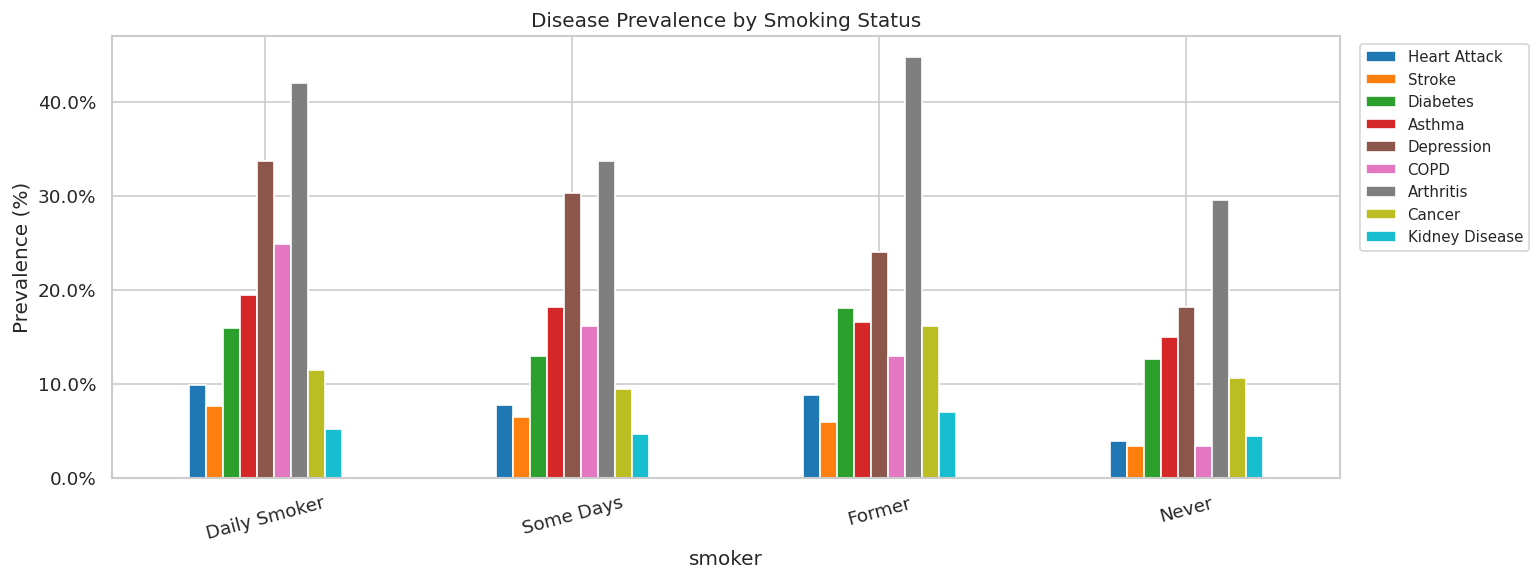

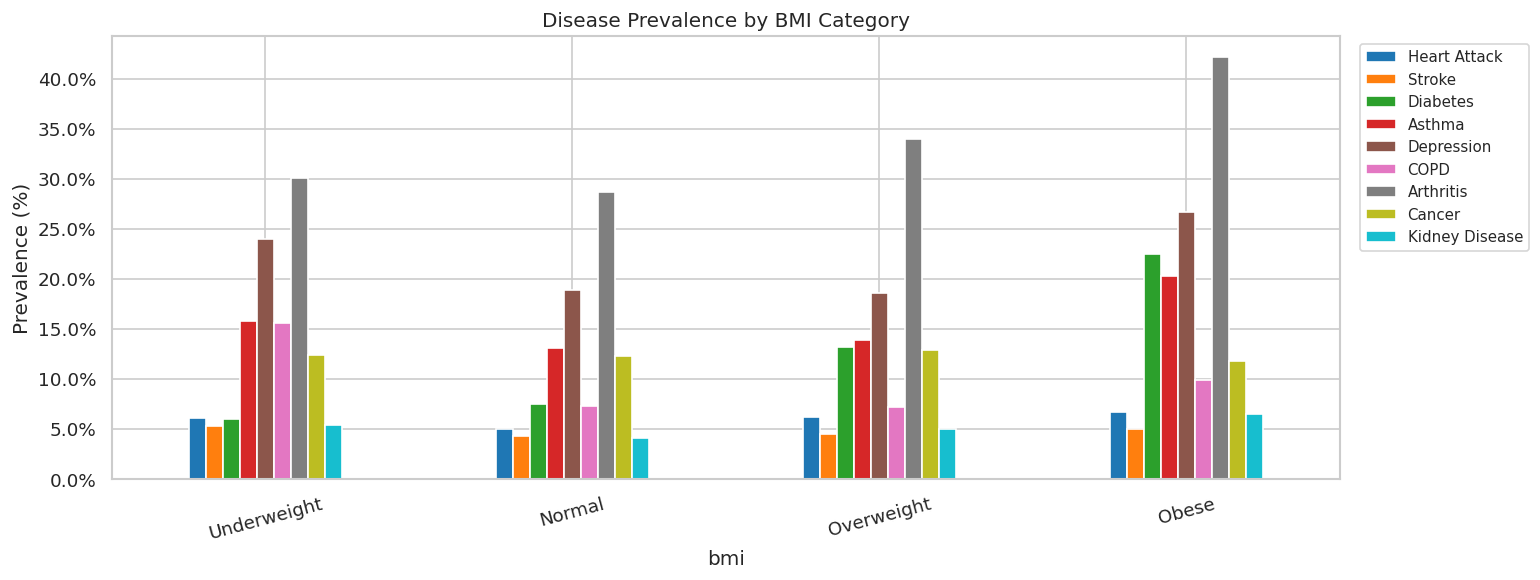

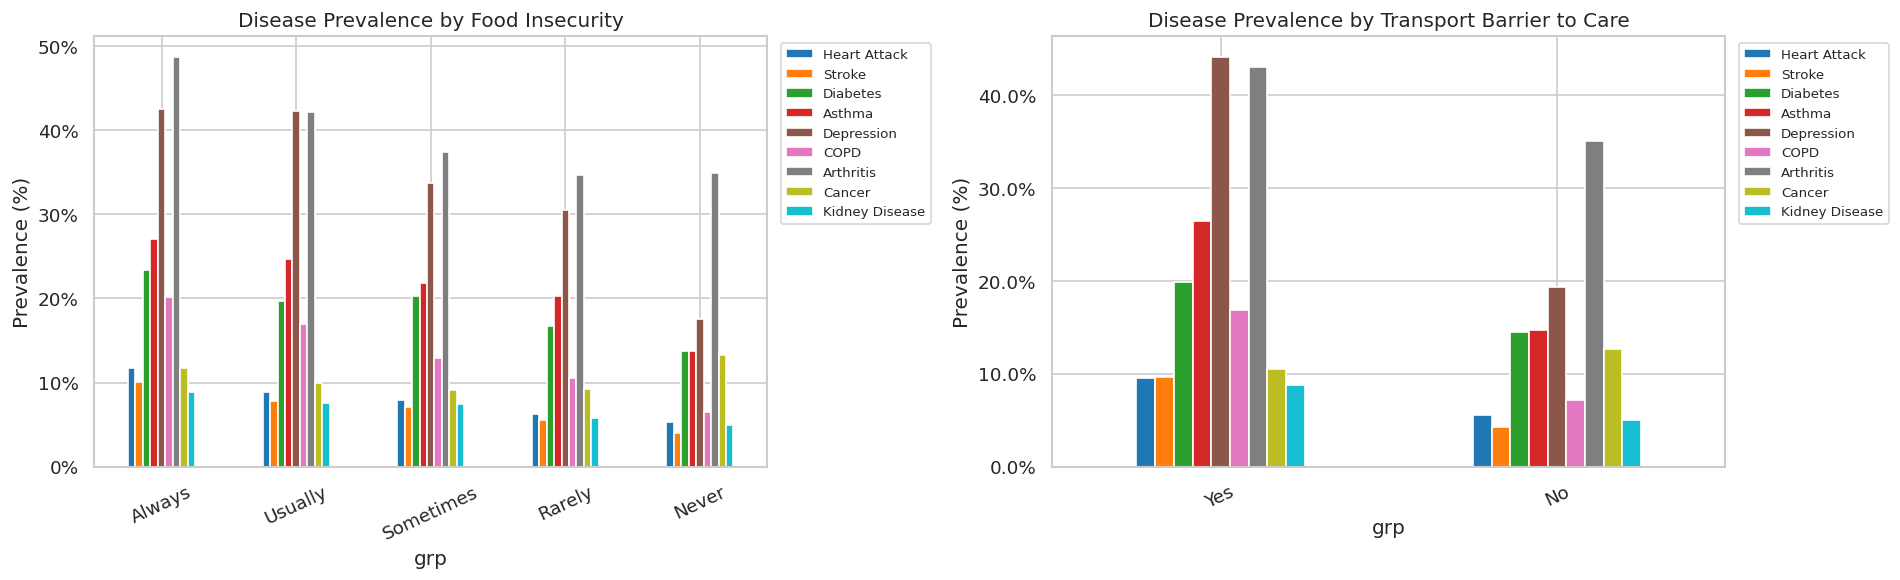

In [ ]:
# ── 9a. Binary outcome co-occurrence matrix ───────────────────
outcome_binary = pd.DataFrame({
    label: (df[col].astype(float) == YES_CODE).astype(float)
    for col, label in OUTCOME_LABELS.items()
})

corr = outcome_binary.corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, vmin=-0.3, vmax=0.6)
ax.set_title("Correlation Between Chronic Disease Diagnoses")
plt.tight_layout()
plt.show()

# ── 9b. Smoking → disease prevalence ─────────────────────────
smoker_map = {1:'Daily Smoker',2:'Some Days',3:'Former',4:'Never'}
smoking_outcome = {}
for col, label in OUTCOME_LABELS.items():
    tmp = df[['_SMOKER3', col]].copy()
    tmp[col]     = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['smoker'] = tmp['_SMOKER3'].astype(float).map(smoker_map)
    smoking_outcome[label] = tmp.dropna().groupby('smoker')[col].mean() * 100

smoke_df = pd.DataFrame(smoking_outcome).reindex(
    [v for v in smoker_map.values() if v in pd.DataFrame(smoking_outcome).index])

fig, ax = plt.subplots(figsize=(13, 5))
smoke_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Disease Prevalence by Smoking Status")
ax.set_ylabel("Prevalence (%)")
ax.tick_params(axis='x', rotation=15)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

# ── 9c. BMI category → disease prevalence ────────────────────
bmi_map = {1:'Underweight', 2:'Normal', 3:'Overweight', 4:'Obese'}
bmi_outcome = {}
for col, label in OUTCOME_LABELS.items():
    tmp = df[['_BMI5CAT', col]].copy()
    tmp[col]    = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['bmi']  = tmp['_BMI5CAT'].astype(float).map(bmi_map)
    bmi_outcome[label] = tmp.dropna().groupby('bmi')[col].mean() * 100

bmi_df = pd.DataFrame(bmi_outcome).reindex(
    [v for v in bmi_map.values() if v in pd.DataFrame(bmi_outcome).index])

fig, ax = plt.subplots(figsize=(13, 5))
bmi_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title("Disease Prevalence by BMI Category")
ax.set_ylabel("Prevalence (%)")
ax.tick_params(axis='x', rotation=15)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

# ── 9d. SDH variables → disease prevalence ───────────────────
sdh_labels = {
    'SDHFOOD1': ({1:'Always',2:'Usually',3:'Sometimes',4:'Rarely',5:'Never'},
                 'Food Insecurity'),
    'SDHTRNSP': ({1:'Yes',2:'No'},
                 'Transport Barrier to Care'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (col, (lbl_map, title)) in zip(axes, sdh_labels.items()):
    sdh_out = {}
    for oc, label in OUTCOME_LABELS.items():
        tmp = df[[col, oc]].copy()
        tmp[oc]    = (tmp[oc].astype(float) == YES_CODE).astype(float)
        tmp['grp'] = tmp[col].astype(float).map(lbl_map)
        sdh_out[label] = tmp.dropna().groupby('grp')[oc].mean() * 100

    sdh_df = pd.DataFrame(sdh_out).reindex(
        [v for v in lbl_map.values() if v in pd.DataFrame(sdh_out).index])
    sdh_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
    ax.set_title(f"Disease Prevalence by {title}")
    ax.set_ylabel("Prevalence (%)")
    ax.tick_params(axis='x', rotation=25)
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

* COPD and Asthma show the strongest pairwise correlation among outcomes, consistent with shared respiratory pathophysiology. Diabetes and Kidney Disease are the second-strongest pair, reflecting the well-established diabetic nephropathy pathway.
* Heart Attack and Stroke co-occur more than either does with any other condition — they should likely be combined into a composite cardiovascular outcome for clustering, or treated as joint anchors for a high-acuity risk tier.
* Depression has low-to-moderate positive correlations with nearly all other conditions, suggesting it functions more as a systemic comorbidity amplifier than as a disease cluster unto itself.
* Smoking shows a clear dose-response relationship: daily smokers have the highest prevalence across almost all nine conditions, former smokers intermediate, never-smokers lowest. The gradient is steepest for COPD (as expected) and also substantial for Heart Attack, Stroke, and Cancer.
* BMI shows the strongest association with Diabetes and Arthritis, moderate associations with Heart Attack and Kidney Disease, and the weakest association with Depression — suggesting BMI is most useful as a metabolic risk feature rather than a mental health predictor in any model.
* Food insecurity (SDHFOOD1) and transportation barriers (SDHTRNSP) both show elevated disease prevalence even at "sometimes" levels of food insecurity — the relationship is graded, not binary, and both SDH variables should be treated as continuous risk signals rather than binary flags.

In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/ADSP 31012 DEPA Final Project/2. EDA and Cleanup/Final Project: Data Extraction-EDA-Cleanup.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/ADSP 31012 DEPA Final Project/2. EDA and Cleanup/Final Project: Data Extraction-EDA-Cleanup.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 20 image(s).
[NbConvertApp] Writing 3437010 bytes to /content/drive/MyDrive/ADSP 31012 DEPA Final Project/2. EDA and Cleanup/Final Project: Data Extraction-EDA-Cleanup.html
